# Objetivo del Script
Predecir el **precio logarítmico de propiedades** en la Ciudad de México utilizando un conjunto de datos con características de la propiedad y servicios cercanos, además de segmentación geográfica mediante clustering.

## Resumen del flujo
1. Cargar datos de propiedades.
2. Limpiar y preprocesar los datos.
3. Realizar ingeniería de características.
4. Aplicar técnicas de clustering geográfico.
5. Entrenar y evaluar diversos modelos de regresión.
6. Seleccionar el mejor modelo basado en métricas de rendimiento.

---

# Archivos de Entrada
- `/content/df_precios_con_servicios (2).csv` → datos de propiedades con precios y servicios

# Archivos de Salida (generados por el script)
- `best_model_*.joblib` → modelos entrenados guardados (e.g., `best_model_XGBoost.joblib`)
- `resultados_experimentacion_corregido_v2.csv` → Resumen de métricas de los modelos

---

# Librerías Utilizadas
- **pandas** → manipulación de datos
- **numpy** → operaciones numéricas
- **matplotlib**, **seaborn** → visualización de datos
- **scikit-learn** → preprocesamiento, clustering, modelos de regresión y métricas
- **xgboost**, **lightgbm** → modelos de Gradient Boosting
- **geopy** → cálculo de distancias geoespaciales

---

# 1. Carga y preprocesamiento inicial de datos

**Acciones**
- Cargar el CSV con los datos de propiedades.
- Eliminar filas con valores nulos en 'Superficie'.
- Filtrar precios y superficies extremos (outliers).
- Filtrar propiedades solo del 'DISTRITO FEDERAL' y eliminar la columna 'Estado'.
- Calcular el logaritmo natural de `Precio_MXN` para `Precio_log` (variable objetivo).
- Visualizar la distribución de `Precio_log` con histograma y QQ-plot.
- Eliminar outliers en 'Baños', 'Estacionamientos' y 'Recamaras'.

**Puntos clave**
- Se realiza una limpieza exhaustiva para asegurar la calidad de los datos.
- Se transforma la variable objetivo a escala logarítmica para mejorar la normalidad y el rendimiento del modelo.

---

# 2. Análisis exploratorio y correlación

**Acciones**
- Generar estadísticas descriptivas para variables numéricas y categóricas.
- Crear scatter plots de `Precio_MXN` vs. otras variables numéricas con líneas de regresión.
- Calcular y visualizar la matriz de correlación entre variables numéricas.

**Puntos clave**
- Entender las relaciones entre las variables y la variable objetivo.
- Identificar posibles multicolinealidades o variables con baja correlación.

---

# 3. Ingeniería de Características

**Acciones**
- Crear nuevas características como `amenities_total` (suma de hospitales, escuelas, etc.), `m2_por_recamaras`, `m2_por_banos`.
- Calcular la distancia geográfica de cada propiedad a puntos de interés clave en la CDMX (Zócalo, Chapultepec, Polanco, etc.) usando `geodesic`.

**Puntos clave**
- Enriquecer el dataset con información relevante para la predicción de precios.
- Capturar la importancia de la ubicación relativa a centros de actividad.

---

# 4. Clustering Geográfico (KMeans)

**Acciones**
- Extraer las coordenadas de latitud y longitud.
- Aplicar el método del codo para determinar un número óptimo de clusters.
- Ejecutar KMeans clustering sobre `Latitud` y `Longitud`.
- Asignar las etiquetas de cluster a cada propiedad en el DataFrame principal.
- Evaluar la calidad del clustering con Silhouette Score y Davies-Bouldin Index.
- Visualizar los clusters geográficos en un mapa de dispersión.

**Puntos clave**
- Segmentar geográficamente las propiedades en grupos para capturar patrones de precios regionales.
- La columna 'kmeans' se utiliza como una característica categórica en los modelos.

---

# 5. Entrenamiento y Evaluación de Modelos

**Acciones**
- Dividir el dataset en conjuntos de entrenamiento y prueba.
- Definir pipelines de preprocesamiento para variables numéricas (imputación, escalado) y categóricas (imputación, `TargetEncoder`).
- Configurar varios modelos de regresión (LinearRegression, Ridge, Lasso, HistGradientBoosting, XGBoost, LightGBM).
- Realizar búsqueda de hiperparámetros (`RandomizedSearchCV`) con validación cruzada para modelos complejos.
- Entrenar los modelos y evaluar su rendimiento utilizando métricas como RMSE, MAE, RMSLE, MAPE (tanto en escala logarítmica como en MXN) y R².
- Guardar los modelos entrenados y los resultados de la experimentación en un CSV.
- Extraer y mostrar las características más importantes de los modelos que lo permiten.

**Puntos clave**
- Comparar el rendimiento de diferentes algoritmos de regresión.
- Utilizar validación cruzada para obtener estimaciones robustas del rendimiento del modelo.
- La variable objetivo `Precio_log` se predice directamente, y luego se transforma de nuevo para obtener métricas en MXN.

In [1]:
import pandas as pd

In [2]:
# Almacenar el archivo en un Dataframe
# df_venta = pd.read_csv('/content/Lamudi_Inmu_10.csv', low_memory=False)
df_venta = pd.read_csv('/content/df_precios_con_servicios (2).csv', low_memory=False)
print(df_venta.shape)

(98217, 26)


In [3]:
# Eliminar las filas con valores nulos en la variable 'Superficie'
df_venta = df_venta[df_venta['Superficie'].notna()]
print(df_venta.shape)

(94573, 26)


In [4]:
df_venta_check = df_venta.copy()

In [5]:
df_venta = df_venta_check

In [6]:
# Mantener las filas con valores entre 500000 y 100000000
df_venta = df_venta[df_venta['Precio_MXN'] > 500000]
df_venta = df_venta[df_venta['Precio_MXN'] < 100000000]

In [7]:
# Mantener solo las filas con propiedades ubicadas en 'DISTRITO FEDERAL'
df_venta = df_venta[df_venta['Estado'] == 'DISTRITO FEDERAL']
df_venta = df_venta.drop(columns=['Estado'])
print(df_venta.shape)

(65217, 25)


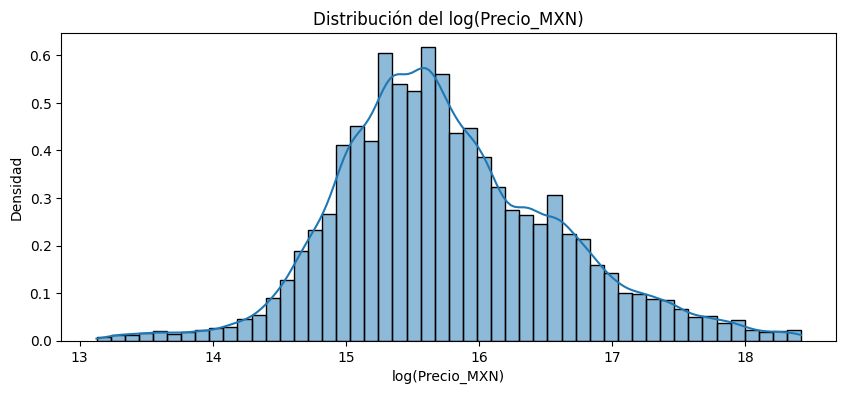

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Obteer el logaritmo natural de la variable 'Precio_MXN'
df_venta['Precio_log'] = np.log(df_venta['Precio_MXN'])

plt.figure(figsize=(10,4))

# Graficar el histograma para observar la distribucion de la variable
sns.histplot(
    df_venta['Precio_log'],
    bins=50,
    kde=True,
    stat="density"
)

plt.title('Distribución del log(Precio_MXN)')
plt.xlabel('log(Precio_MXN)')
plt.ylabel('Densidad')
plt.show()


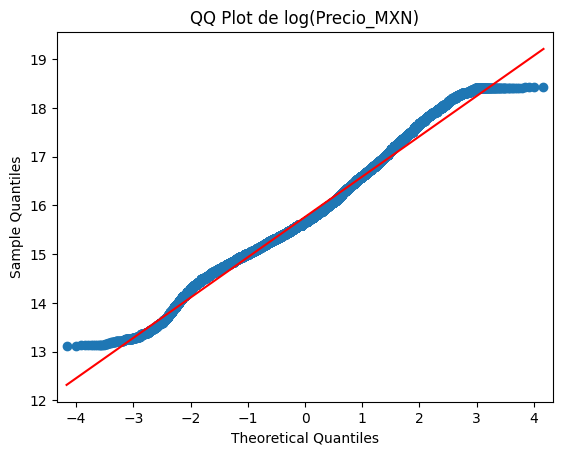

In [12]:
import statsmodels.api as sm

# Graficar el QQ_plot de la variable 'Precio_log' para ver cuanto se aproxima a una distribucion normal
sm.qqplot(df_venta['Precio_log'], line='s')
plt.title('QQ Plot de log(Precio_MXN)')
plt.show()

In [13]:
df_venta.describe()

,Estacionamientos,Precio_MXN,Superficie,Recamaras,Baños,Hospitales,Escuelas,Esparcimiento,Restaurantes,Carpetas,Transporte,Parques,Latitud,Longitud,Precio_log
count,51156.000000,6.521700e+04,6.521700e+04,64408.000000,64104.000000,54803.000000,54803.000000,54803.000000,54803.000000,54803.000000,54803.000000,54512.000000,54803.000000,54803.000000,65217.000000
mean,2.147392,1.026189e+07,3.640092e+02,2.526503,2.262480,9.387917,131.078426,23.613032,910.206522,3179.854004,135.830374,26.760530,19.389603,-99.186007,15.763434
std,1.712994,1.169813e+07,2.770564e+04,1.976317,1.472848,10.138960,67.824362,25.712925,695.190523,2309.259164,73.373179,18.136934,0.052160,0.052524,0.826387
min,1.000000,5.020000e+05,1.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.129074,-99.333119,13.126355
25%,1.000000,4.047685e+06,7.200000e+01,2.000000,2.000000,2.000000,82.000000,3.000000,341.000000,1167.000000,69.000000,11.000000,19.357515,-99.218115,15.213656
50%,2.000000,6.300000e+06,1.190000e+02,2.000000,2.000000,6.000000,121.000000,13.000000,749.000000,2726.000000,128.000000,24.000000,19.394237,-99.174171,15.656060
75%,2.000000,1.170000e+07,2.500000e+02,3.000000,3.000000,12.000000,179.000000,39.000000,1336.000000,4661.000000,201.000000,41.000000,19.429379,-99.157997,16.275099
max,50.000000,9.999899e+07,5.000000e+06,366.000000,89.000000,40.000000,262.000000,88.000000,2736.000000,8758.000000,285.000000,158.000000,19.574425,-98.975505,18.420671


In [14]:
# estadistica descriptiva variables no numericas
df_venta.describe(include='object')

,Direccion,Colonia,Municipio,Fecha,Seguridad,Balcon,Piscina,Jardin,Terraza,Tipo,Web
count,65217,65217,65217,65217,63962,63962,63962,63962,63962,64882,65217
unique,1133,1003,16,8,2,2,2,2,2,2,2
top,"Bosques de las Lomas, Cuajimalpa de Morelos, C...",BOSQUE DE LAS LOMAS,CUAUHTEMOC,2025-07-01,False,False,False,False,False,Departamento,Lamudi
freq,3217,3663,14799,22449,60915,63181,63052,63317,61250,51007,63962


In [ ]:
# quitar outliers de df_venta en la columna precio_mxn
# df_venta = df_venta[(df_venta['Precio_MXN'] < df_venta['Precio_MXN'].quantile(0.95)) & (df_venta['Precio_MXN'] > df_venta['Precio_MXN'].quantile(0.05))]
# print(df_venta.shape)

In [15]:
# Eliminar outliers de la variable 'Superficie'
df_venta = df_venta[(df_venta['Superficie'] < df_venta['Superficie'].quantile(0.95)) & (df_venta['Superficie'] > df_venta['Superficie'].quantile(0.05))]
print(df_venta.shape)

(58593, 26)


In [16]:
# Eliminar outliers de las variables 'Baños', 'Estacionamientos' y 'Recamaras'
df_venta = df_venta[df_venta['Baños'] < df_venta['Baños'].quantile(0.99)]
df_venta = df_venta[df_venta['Estacionamientos'] < df_venta['Estacionamientos'].quantile(0.99)]
df_venta = df_venta[df_venta['Recamaras'] < df_venta['Recamaras'].quantile(0.99)]
print(df_venta.shape)

(43772, 26)


In [17]:
# Obtener informacion relevante de todo el conjunto de datos
print(df_venta.head())
print('---'*15)
print(df_venta.info())
print('---'*15)
print(df_venta.describe())

                                           Direccion  Estacionamientos  \
0            Del Gas, Azcapotzalco, Ciudad de México               1.0   
2         Del Recreo, Azcapotzalco, Ciudad de México               1.0   
3            Del Gas, Azcapotzalco, Ciudad de México               2.0   
4            Del Gas, Azcapotzalco, Ciudad de México               1.0   
5  Azcapotzalco Centro, Azcapotzalco, Ciudad de M...               1.0   

   Precio_MXN  Superficie  Recamaras  Baños              Colonia  \
0   2586432.0        64.0        2.0    2.0              DEL GAS   
2   3400000.0       100.0        3.0    2.0           DEL RECREO   
3   3400000.0        78.0        3.0    2.0              DEL GAS   
4   2300000.0        60.0        2.0    1.0              DEL GAS   
5   2808291.0        52.0        2.0    1.0  AZCAPOTZALCO CENTRO   

      Municipio       Fecha Seguridad  ... Hospitales Escuelas Esparcimiento  \
0  AZCAPOTZALCO  2025-07-01     False  ...        6.0    102.0    

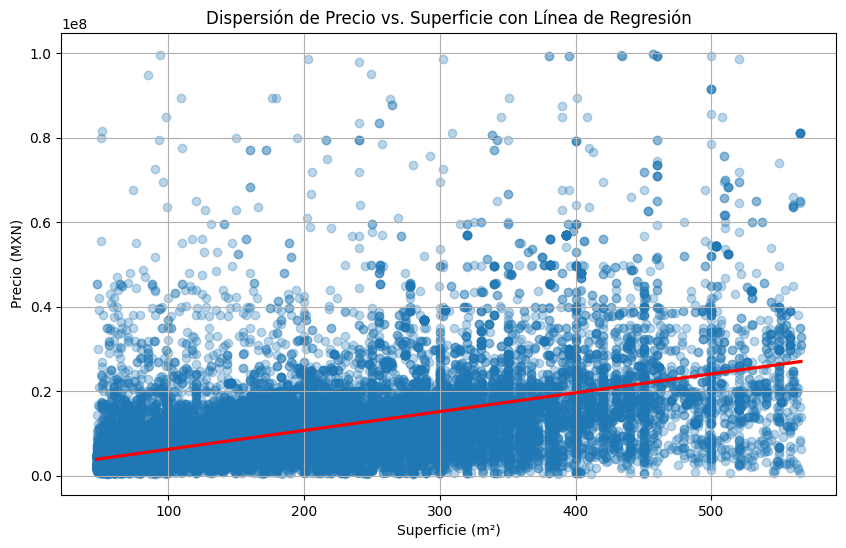

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear el gráfico de dispersión con línea de regresión
plt.figure(figsize=(10, 6))
sns.regplot(x='Superficie', y='Precio_MXN', data=df_venta,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Dispersión de Precio vs. Superficie con Línea de Regresión')
plt.xlabel('Superficie (m²)')
plt.ylabel('Precio (MXN)')
plt.grid(True)
plt.show()

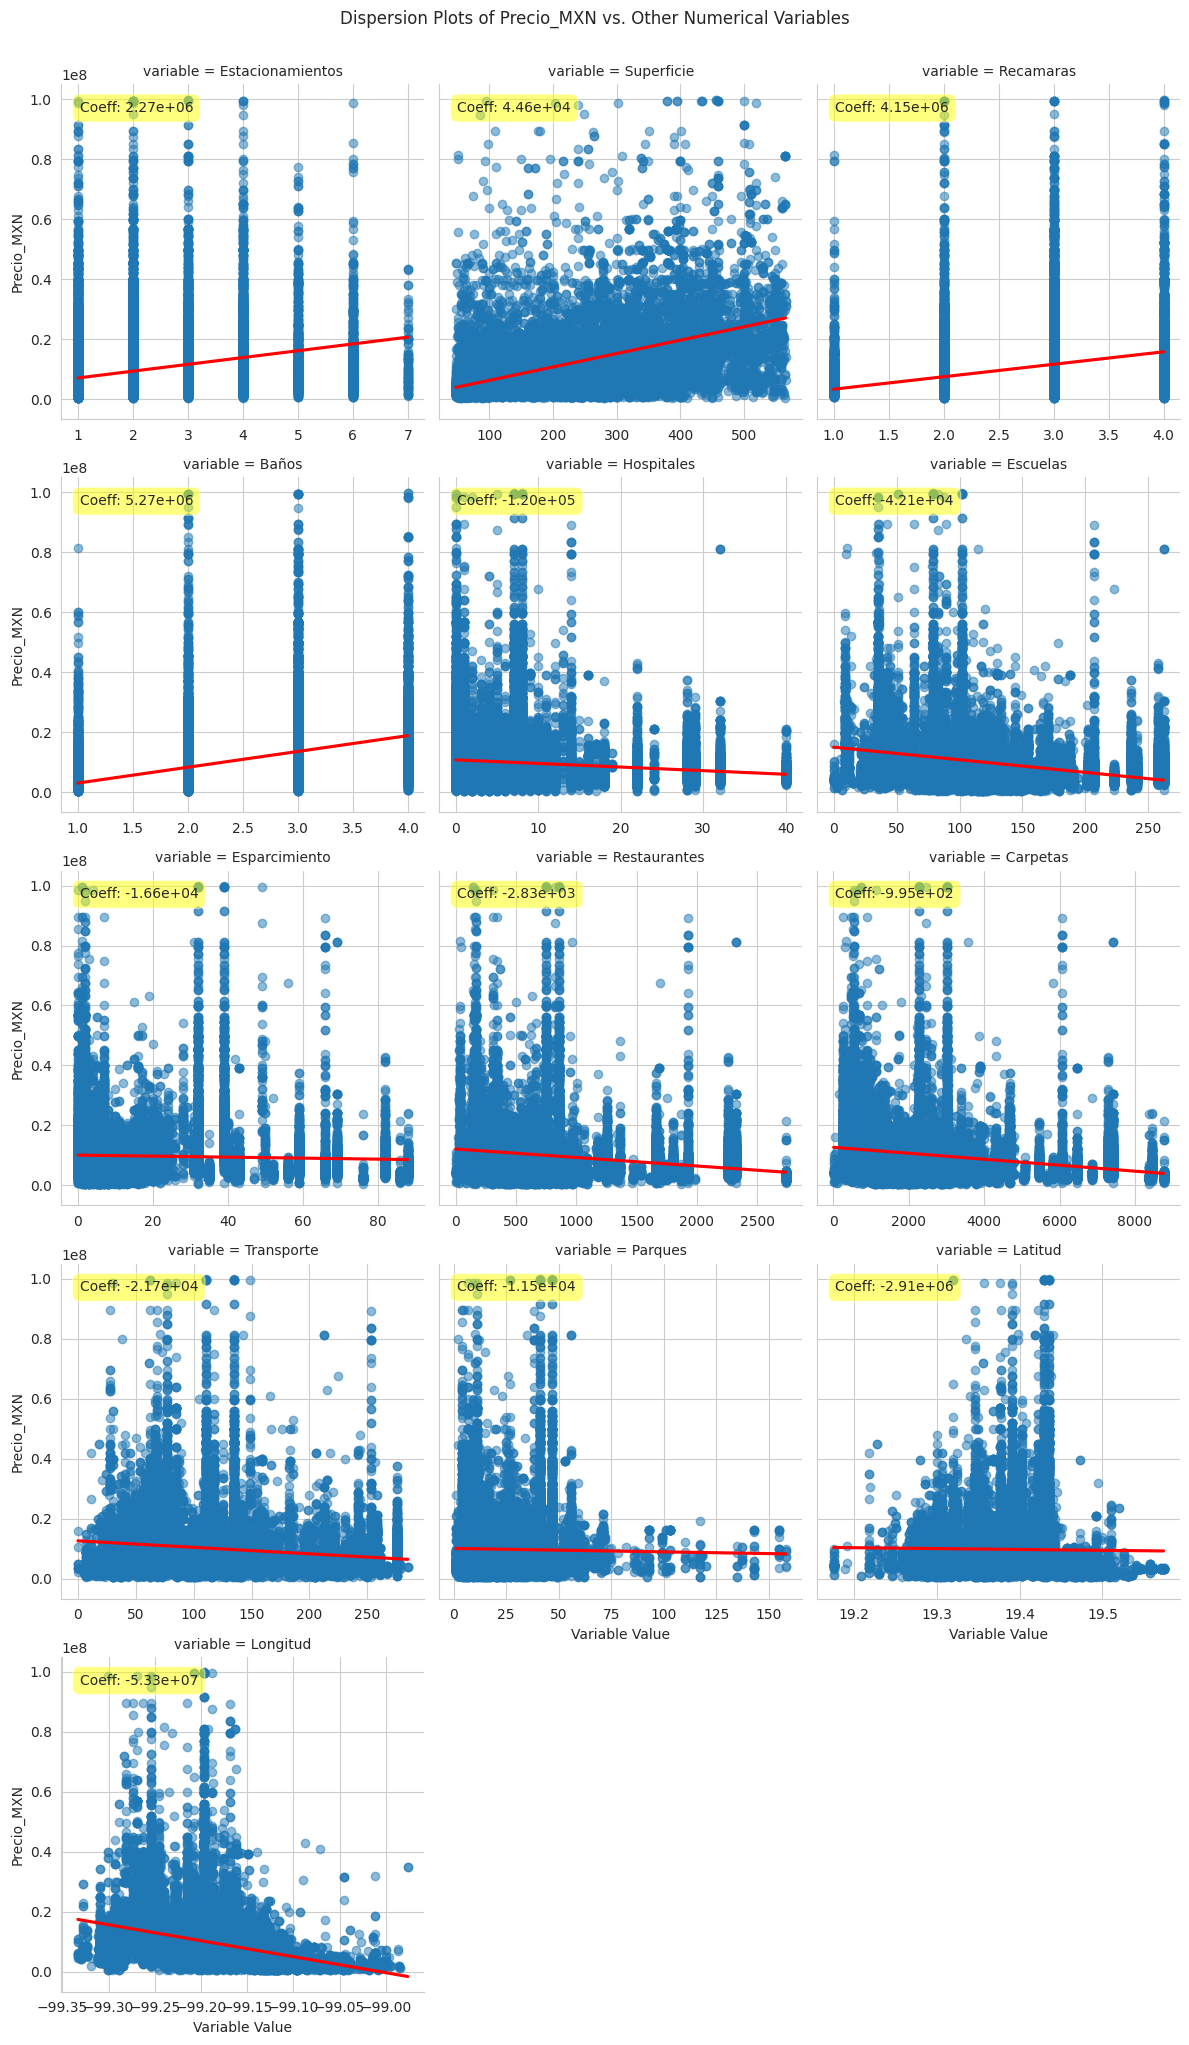

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

df_long = df_venta.melt(
    id_vars="Precio_MXN",
    var_name="variable",
    value_name="valor"
)

# Lista de variables numericas para graficar con Precio_MXN
numerical_cols_for_x = [
    'Estacionamientos', 'Superficie', 'Recamaras', 'Baños',
    'Hospitales', 'Escuelas', 'Esparcimiento', 'Restaurantes',
    'Carpetas', 'Transporte', 'Parques', 'Latitud', 'Longitud'
]

# FFiltrar solo las variables numericas para poder graficar
df_long_numeric = df_long[df_long['variable'].isin(numerical_cols_for_x)].copy()

# Asegurar que la variable 'valor' sea numerica
df_long_numeric['valor'] = pd.to_numeric(df_long_numeric['valor'], errors='coerce')

# Borrar filas que tienen valores NaN despues de la conversion
df_long_numeric.dropna(subset=['valor'], inplace=True)

# Calcular los coeficientes de la regresion para cada variable
coefficients = {}
for var in numerical_cols_for_x:
    subset_df = df_long_numeric[df_long_numeric['variable'] == var]
    if not subset_df.empty:
        x_data = subset_df['valor'].values
        y_data = subset_df['Precio_MXN'].values
        valid_indices = ~np.isnan(x_data) & ~np.isnan(y_data)
        x_data = x_data[valid_indices]
        y_data = y_data[valid_indices]

        if len(x_data) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)
            coefficients[var] = slope
        else:
            coefficients[var] = None


# Crear los scatter plots con regresión lineal y facet
g = sns.lmplot(
    data=df_long_numeric,
    x="valor",
    y="Precio_MXN",
    col="variable",
    col_wrap=3,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"},
    ci=None,
    height=4,
    facet_kws={"sharex": False}
)

g.fig.suptitle("Dispersion Plots of Precio_MXN vs. Other Numerical Variables", y=1.02)
g.set_axis_labels("Variable Value", "Precio_MXN")

# Añadir coeficientes como etiquetas para cada grafica
for ax in g.axes.flat:
    title_text = ax.get_title()
    if 'variable = ' in title_text:
        var_name = title_text.split('variable = ')[1]
    else:
        var_name = title_text

    if var_name in coefficients and coefficients[var_name] is not None:
        coeff = coefficients[var_name]
        ax.text(0.05, 0.95, f'Coeff: {coeff:.2e}', transform=ax.transAxes,
                fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

plt.show()

In [21]:
# Matriz de correlación entre variables numericas
df_for_corr = df_venta[['Precio_MXN', 'Estacionamientos', 'Superficie', 'Recamaras', 'Baños', 'Seguridad', 'Balcon', 'Piscina', 'Jardin', 'Terraza', 'Hospitales', 'Escuelas', 'Esparcimiento', 'Restaurantes', 'Transporte', 'Latitud', 'Longitud', 'Tipo']].copy()

numeric_X_with_price = df_for_corr.select_dtypes(include=['int64', 'float64', 'Float64'])
corr_matrix = numeric_X_with_price.corr()
print(corr_matrix)

                  Precio_MXN  Estacionamientos  Superficie  Recamaras  \
Precio_MXN          1.000000          0.280315    0.582479   0.344081   
Estacionamientos    0.280315          1.000000    0.403400   0.301468   
Superficie          0.582479          0.403400    1.000000   0.537615   
Recamaras           0.344081          0.301468    0.537615   1.000000   
Baños               0.462504          0.333831    0.556649   0.608794   
Hospitales         -0.124585         -0.285268   -0.301402  -0.283621   
Escuelas           -0.285339         -0.396717   -0.464457  -0.416770   
Esparcimiento      -0.041570         -0.308132   -0.303609  -0.359894   
Restaurantes       -0.192657         -0.386309   -0.423159  -0.420319   
Transporte         -0.164134         -0.334027   -0.364245  -0.343940   
Latitud            -0.015839         -0.264376   -0.249630  -0.259165   
Longitud           -0.300751         -0.333494   -0.353700  -0.177170   

                     Baños  Hospitales  Escuelas  

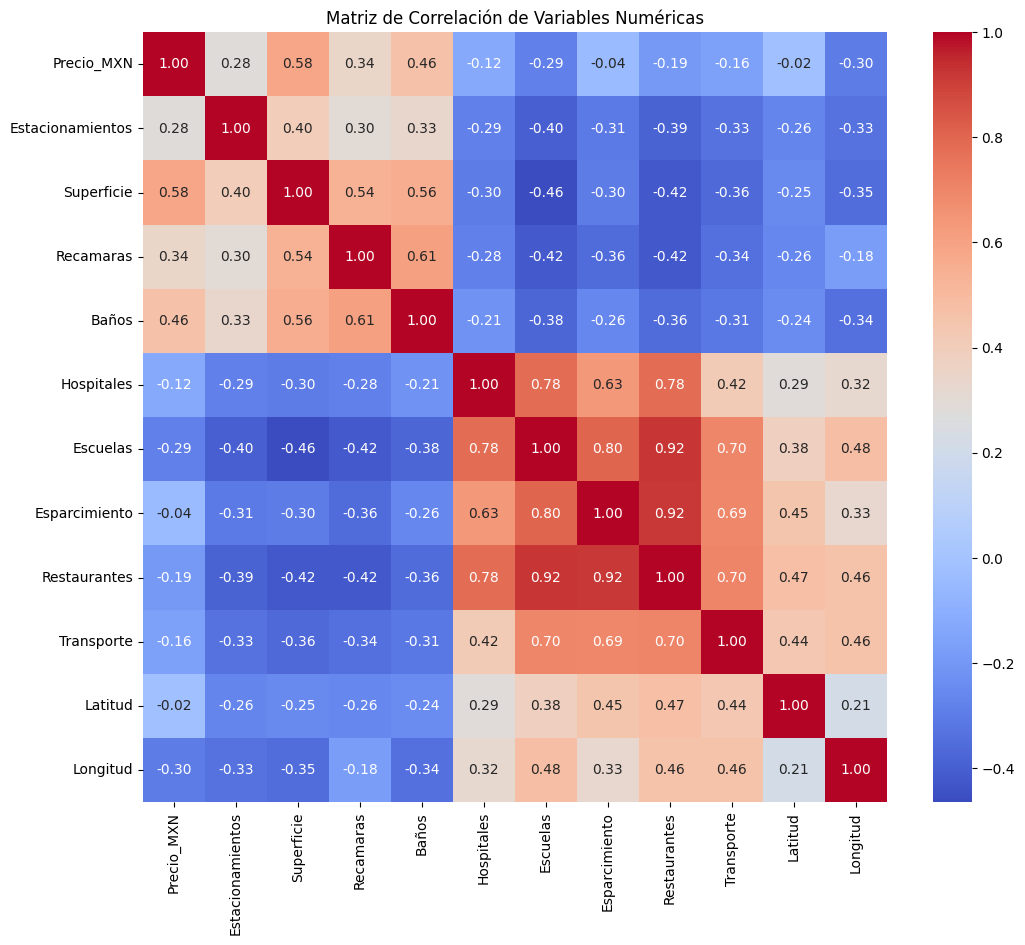

In [22]:
import seaborn as sns

# Graficar la matriz de correlacion
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

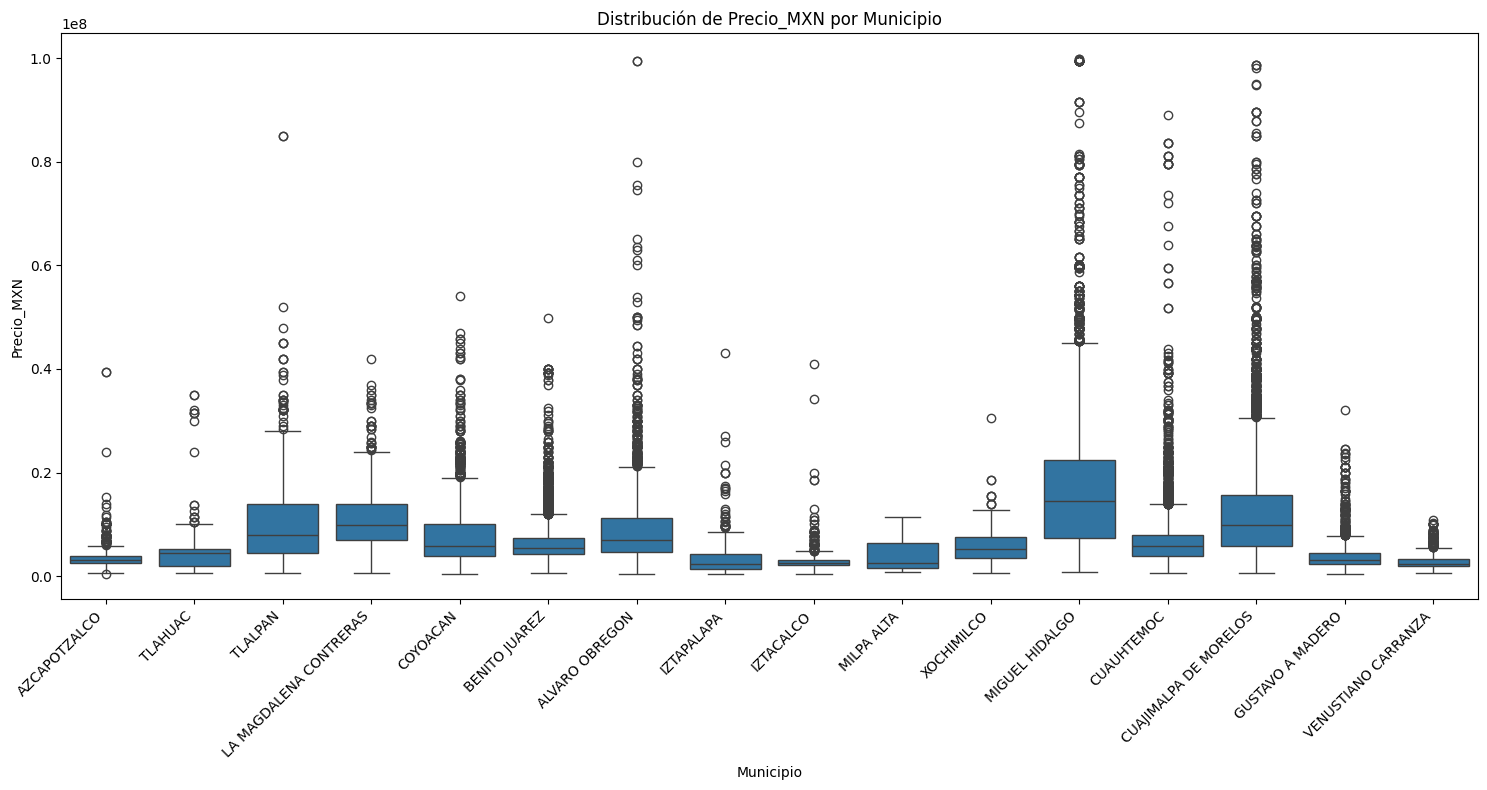

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='Municipio', y='Precio_MXN', data=df_venta)
plt.title('Distribución de Precio_MXN por Municipio')
plt.xlabel('Municipio')
plt.ylabel('Precio_MXN')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# obtener unicamente latitud y longitud y borrar valores nulos
df_geo = df_venta[['Latitud', 'Longitud']].copy()
df_geo.dropna(inplace=True)

print(df_geo.head())
print(f"Shape of df_geo after dropping NaNs: {df_geo.shape}")

     Latitud   Longitud
0  19.470454 -99.156672
2  19.473118 -99.184571
3  19.470454 -99.156672
4  19.470454 -99.156672
6  19.487482 -99.212095
Shape of df_geo after dropping NaNs: (36163, 2)


In [ ]:
from sklearn.cluster import KMeans
ssd = []
K = range(1,11) # probar el numero de clusters de 1 a 10
RANDOM_STATE = 42
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(df_geo)
    ssd.append(kmeans.inertia_)

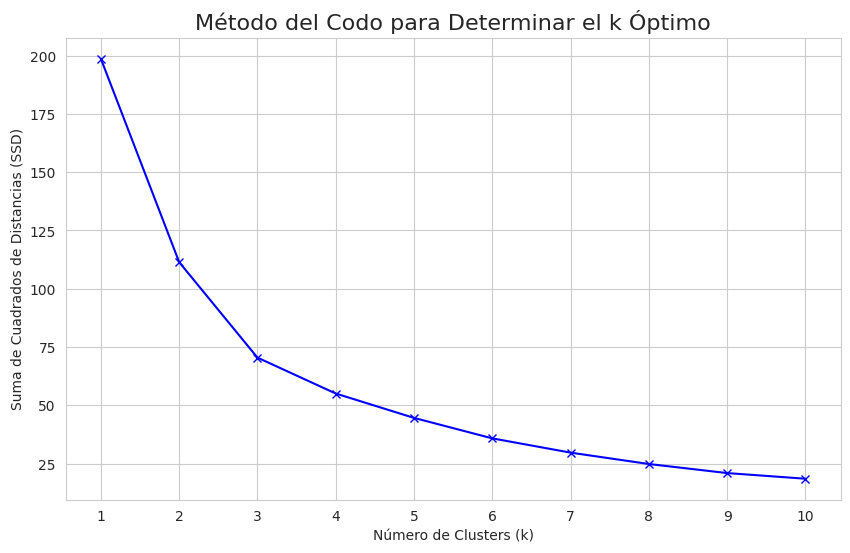

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
plt.plot(K, ssd, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Suma de Cuadrados de Distancias (SSD)')
plt.title('Método del Codo para Determinar el k Óptimo', fontsize=16)
plt.xticks(K)
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans

# Suponiendo que optima_k y RANDOM_STATE se definan en pasos de agrupación anteriores
# De lo contrario, sería necesario establecerlos o derivarlos explícitamente.
RANDOM_STATE = 42
for optimal_k in [2, 3, 4, 5]:
# optimal_k = 3 # basado en el metodo del codo

    # Paso 1: Vuelva a extraer los datos geográficos del 'df' actual
    df_geo_current = df_venta[['Latitud', 'Longitud']].dropna().copy()

    # Paso 2: Vuelva a ejecutar la agrupación en clústeres de KMeans
    kmeans_model_temp = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
    cluster_labels_temp = kmeans_model_temp.fit_predict(df_geo_current)

    # Paso 3: Asignar las nuevas etiquetas del clúster al 'df' principal
    # Esto garantiza la alineación con el índice de df original donde estaban presentes Lat/Long
    # No asignar a df_venta directamente en este bucle, solo usar para evaluación

    # Preparar datos para evaluación usando las etiquetas temporales
    X_eval = df_geo_current # Las coordenadas geográficas son las características
    labels_eval = cluster_labels_temp # Las etiquetas temporales del clúster

    # Calcular el Silhouette Score
    silhouette = silhouette_score(X_eval, labels_eval)

    # Calcular el índice de Davies-Bouldin
    davies_bouldin = davies_bouldin_score(X_eval, labels_eval)

    # Imprimir los resultados
    print(f"k = {optimal_k}")
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")

k = 2
Silhouette Score: 0.4567
Davies-Bouldin Index: 0.9489
k = 3
Silhouette Score: 0.4658
Davies-Bouldin Index: 0.8442
k = 4
Silhouette Score: 0.4396
Davies-Bouldin Index: 0.8928
k = 5
Silhouette Score: 0.4371
Davies-Bouldin Index: 0.8311


In [ ]:
optimal_k = 3 # elegido por el metodo del codo

kmeans_model = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_model.fit_predict(df_geo)

# Primero agregue etiquetas de clúster al marco de datos df_geo para alinear correctamente
df_geo['cluster_label'] = cluster_labels

# combinar estas etiquetas nuevamente con el df DataFrame original
# Necesitamos asegurarnos de que la combinación se realice correctamente según el índice.
# Dado que df_geo se creó eliminando NaN de df, debemos alinear por índice.
# Completaremos los valores NaN en 'cluster_label' para las filas que se eliminaron de df_geo con un marcador de posición.

# Cree una serie vacía con el mismo índice que el df original
full_cluster_labels = pd.Series(np.nan, index=df_venta.index)

# Complete la Serie con las etiquetas del clúster donde existen datos en df_geo
full_cluster_labels.loc[df_geo.index] = df_geo['cluster_label']

df_venta['cluster_label'] = full_cluster_labels

print(f"Shape of df after adding cluster labels: {df_venta.shape}")
print(f"Value counts for the new 'cluster_label' column:\n{df_venta['cluster_label'].value_counts(dropna=False)}")
print("KMeans clustering applied and cluster labels added to df_venta.")

Shape of df after adding cluster labels: (43772, 27)
Value counts for the new 'cluster_label' column:
cluster_label
0.0    17402
2.0     9768
1.0     8993
NaN     7609
Name: count, dtype: int64
KMeans clustering applied and cluster labels added to df_venta.


In [ ]:
if 'cluster_label' in df_venta.columns:
    df_venta['kmeans'] = df_venta['cluster_label']
    df_venta.drop(columns=['cluster_label'], inplace=True)
    print("Column 'cluster_label' renamed to 'kmeans' successfully.")
    print(df_venta[['Latitud', 'Longitud', 'kmeans']].head())
else:
    print("Column 'cluster_label' not found in df. Please ensure KMeans clustering was executed.")

Column 'cluster_label' renamed to 'kmeans' successfully.
     Latitud   Longitud  kmeans
0  19.470454 -99.156672     0.0
2  19.473118 -99.184571     0.0
3  19.470454 -99.156672     0.0
4  19.470454 -99.156672     0.0
5        NaN        NaN     NaN


In [ ]:
# 1. Aseguramos que la columna sea tratada como categoría
# Primero la convertimos a objeto/string para evitar que el ".0" confunda
df_venta['kmeans'] = df_venta['kmeans'].astype(str).replace('nan', 'Sin Cluster')

# 2. Convertimos formalmente al tipo 'category' de pandas
df_venta['kmeans'] = df_venta['kmeans'].astype('category')

print(f"Tipo de dato de 'kmeans': {df_venta['kmeans'].dtype}")
print("\nDistribución final de categorías:")
print(df_venta['kmeans'].value_counts(dropna=False))

# Verificación rápida
print("\nPrimeras filas con la nueva categoría:")
print(df_venta[['Latitud', 'Longitud', 'kmeans']].head())

Tipo de dato de 'kmeans': category

Distribución final de categorías:
kmeans
0.0            17402
2.0             9768
1.0             8993
Sin Cluster     7609
Name: count, dtype: int64

Primeras filas con la nueva categoría:
     Latitud   Longitud       kmeans
0  19.470454 -99.156672          0.0
2  19.473118 -99.184571          0.0
3  19.470454 -99.156672          0.0
4  19.470454 -99.156672          0.0
5        NaN        NaN  Sin Cluster


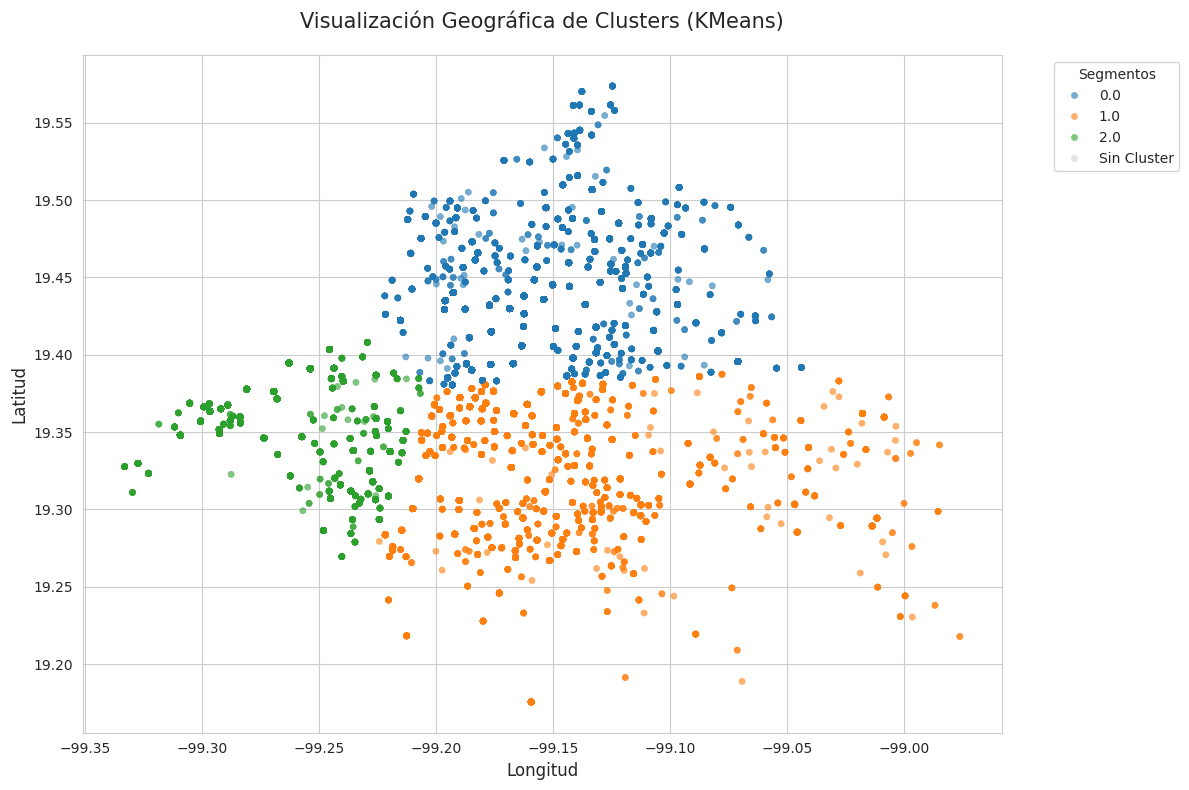

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Definimos una paleta de colores vibrante para los clusters
# y dejamos el gris para los puntos "Sin Cluster"
palette = {
    '0.0': '#1f77b4', # Azul
    '1.0': '#ff7f0e', # Naranja
    '2.0': '#2ca02c', # Verde
    'Sin Cluster': '#d3d3d3' # Gris claro
}

# Graficamos
map_plot = sns.scatterplot(
    data=df_venta,
    x='Longitud',
    y='Latitud',
    hue='kmeans',
    palette=palette,
    alpha=0.6,
    s=20,
    edgecolor=None
)

# Personalización estética
plt.title('Visualización Geográfica de Clusters (KMeans)', fontsize=15, pad=20)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend(title='Segmentos', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustamos los límites para ignorar posibles outliers extremos si los hay
# (Opcional: puedes comentar estas líneas si quieres ver todo el espectro)
plt.autoscale()

plt.tight_layout()
plt.show()

In [ ]:
import os
import sys
import joblib
import warnings
import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_squared_log_error, mean_absolute_percentage_error, make_scorer

# Librerías de Boosting
import xgboost as xgb
import lightgbm as lgb
try:
    from catboost import CatBoostRegressor
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "catboost"])
    from catboost import CatBoostRegressor

from scipy.stats import randint, uniform
from geopy.distance import geodesic

RANDOM_STATE = 42

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ==========================================
# 1. FUNCIONES AUXILIARES Y MÉTRICAS
# ==========================================

def keep_top_k_categories(series: pd.Series, k: int):
    topk = series.value_counts().nlargest(k).index
    return series.where(series.isin(topk), other="Other")

def reduce_high_card_cols(df: pd.DataFrame, cols_topk_map: dict):
    df = df.copy()
    for col, k in cols_topk_map.items():
        if col in df.columns:
            df[col] = keep_top_k_categories(df[col].astype("object").fillna("Missing"), k)
    return df

# Métricas Logarítmicas
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def mape(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred)

# Métricas Transformadas a MXN (Reales)
def rmse_mxn_from_log(y_log_true, y_log_pred):
    return rmse(np.exp(y_log_true), np.exp(y_log_pred))

def mae_mxn_from_log(y_log_true, y_log_pred):
    return mae(np.exp(y_log_true), np.exp(y_log_pred))

def mape_mxn_from_log(y_log_true, y_log_pred):
    return mape(np.exp(y_log_true), np.exp(y_log_pred))

neg_rmse_scorer = make_scorer(lambda y_true, y_pred: -rmse(y_true, y_pred), greater_is_better=True)

# ==========================================
# 2. CARGA Y PREPROCESAMIENTO BÁSICO
# ==========================================
# Asumimos que df_venta ya está cargado en el entorno
df = df_venta.copy()
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

TARGET = "Precio_log"
if TARGET not in df.columns:
    raise KeyError(f"No encuentro la columna target '{TARGET}' en el dataset.")

# Limpieza de Data Leakage (Variables de precio)
possible_leak_cols = [c for c in df.columns if c.lower() in ("precio_mxn", "precio_mx", "precio", "price_mxn", "precio_m") and c != TARGET]
df = df.drop(columns=possible_leak_cols, errors='ignore')

# Tipado de booleanas
bool_cols = ["Seguridad", "Balcon", "Piscina", "Jardin", "Terraza"]
for c in bool_cols:
    if c in df.columns:
        df[c] = df[c].map({True: 1, False: 0, "True": 1, "False": 0}).astype("Float64")

# Top-K Categorías
cols_topk_map = {c: 50 for c in ["Colonia", "Municipio", "Tipo"] if c in df.columns}
if cols_topk_map:
    df = reduce_high_card_cols(df, cols_topk_map)

# Feature Engineering
if all(c in df.columns for c in ['Hospitales', 'Escuelas', 'Esparcimiento', 'Restaurantes', 'Parques']):
    df['amenities_total'] = df["Hospitales"] + df["Escuelas"] + df["Esparcimiento"] + df["Restaurantes"] + df["Parques"]
    df.drop(columns=['Hospitales', 'Escuelas', 'Esparcimiento', 'Restaurantes', 'Parques'], inplace=True)

df["m2_por_recamaras"] = df["Superficie"] / (df["Recamaras"] + 1)
df["m2_por_banos"] = df["Superficie"] / (df["Baños"] + 1)

# Distancias Geodésicas
locations = {
    "zocalo": (19.4326, -99.1332),
    "chapultepec": (19.4204, -99.1819),
    "polanco": (19.4333, -99.2000),
    "santa_fe": (19.3619, -99.2726),
    "roma_norte": (19.4194, -99.1607)
    # Agrega más si lo deseas
}

for loc_name, coords in locations.items():
    if "Latitud" in df.columns and "Longitud" in df.columns:
        df[f"dist_{loc_name}"] = df.apply(
            lambda row: geodesic((row["Latitud"], row["Longitud"]), coords).km
            if pd.notna(row["Latitud"]) and pd.notna(row["Longitud"]) else np.nan,
            axis=1
        )

# ==========================================
# 3. SPLIT Y PIPELINES DE TRANSFORMACIÓN
# ==========================================
X = df.drop(columns=[TARGET])
y = df[TARGET].values

drop_cols = ["Direccion", "Fecha", "Web"]
X = X.drop(columns=[c for c in drop_cols if c in X.columns])

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
print(f"\nDimensiones - Train: {X_train.shape}, Test: {X_test.shape}")

numeric_cols = X_train.select_dtypes(include=["int64", "float64", "Float64"]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

# Pipeline Numérico: Imputación + Escalado (previene leakage de media/desviación)
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Pipeline Categórico: Imputación + Target Encoding
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", TargetEncoder(smooth=10))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
], remainder="drop")

# ==========================================
# 4. DEFINICIÓN DE MODELOS DE ENSAMBLE Y ESPACIOS DE BÚSQUEDA
# ==========================================
# Se incluyen regularizadores agresivos (L1/L2) y submuestreo para evitar overfitting

models_and_params = {
    "RandomForest": {
        "model": Pipeline([("pre", preprocessor), ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))]),
        "params": {
            "model__n_estimators": randint(150, 400),
            "model__max_depth": [None, 15, 20, 25],
            "model__min_samples_split": randint(2, 10),
            "model__min_samples_leaf": randint(1, 5),
            "model__max_features": ['sqrt', 'log2', 1.0]
        }
    },
    "XGBoost": {
        "model": Pipeline([("pre", preprocessor), ("model", xgb.XGBRegressor(objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=-1))]),
        "params": {
            "model__n_estimators": randint(100, 400),
            "model__learning_rate": uniform(0.01, 0.15),
            "model__max_depth": randint(4, 12),
            "model__subsample": uniform(0.6, 0.4),          # [0.6, 1.0]
            "model__colsample_bytree": uniform(0.6, 0.4),   # [0.6, 1.0]
            "model__reg_alpha": uniform(0, 5.0),            # L1 Regularization
            "model__reg_lambda": uniform(1.0, 5.0)          # L2 Regularization
        }
    },
    "LightGBM": {
        "model": Pipeline([("pre", preprocessor), ("model", lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))]),
        "params": {
            "model__n_estimators": randint(100, 400),
            "model__learning_rate": uniform(0.01, 0.15),
            "model__max_depth": randint(4, 15),
            "model__num_leaves": randint(30, 150),
            "model__subsample": uniform(0.6, 0.4),
            "model__colsample_bytree": uniform(0.6, 0.4),
            "model__reg_alpha": uniform(0, 5.0),            # L1
            "model__reg_lambda": uniform(1.0, 5.0)          # L2
        }
    },
    "CatBoost": {
        "model": Pipeline([("pre", preprocessor), ("model", CatBoostRegressor(random_state=RANDOM_STATE, verbose=False))]),
        "params": {
            "model__iterations": randint(150, 500),
            "model__learning_rate": uniform(0.01, 0.15),
            "model__depth": randint(4, 10),
            "model__l2_leaf_reg": uniform(1, 10),           # L2
            "model__subsample": uniform(0.6, 0.4)
        }
    }
}

# ==========================================
# 5. ENTRENAMIENTO Y EVALUACIÓN CRUZADA
# ==========================================
results = []
# Validación cruzada K-Fold robusta (5 pliegues)
cv_outer = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for model_name, mp in models_and_params.items():
    print(f"\n" + "="*40)
    print(f"ENTRENANDO MODELO: {model_name}")
    print("="*40)

    pipeline = mp["model"]
    params = mp["params"]

    # RandomizedSearchCV (30 iteraciones para exploración profunda)
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=params,
        n_iter=30,
        scoring=neg_rmse_scorer,
        cv=cv_outer,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
        verbose=1,
        error_score="raise"
    )

    # Entrenamiento general
    search.fit(X_train, y_train)
    best_est = search.best_estimator_

    print(f"\nMejores hiperparámetros encontrados:\n{search.best_params_}")

    # Predicciones
    y_pred_log_train = best_est.predict(X_train)
    y_pred_log_test = best_est.predict(X_test)

    # Cálculo de métricas
    train_r2 = r2_score(y_train, y_pred_log_train)
    test_r2 = r2_score(y_test, y_pred_log_test)

    train_rmse_log = rmse(y_train, y_pred_log_train)
    test_rmse_log = rmse(y_test, y_pred_log_test)

    train_mae_log = mae(y_train, y_pred_log_train)
    test_mae_log = mae(y_test, y_pred_log_test)

    train_mape_log = mape(y_train, y_pred_log_train)
    test_mape_log = mape(y_test, y_pred_log_test)

    # Métricas en su escala original (Pesos Mexicanos MXN)
    train_rmse_mxn = rmse_mxn_from_log(y_train, y_pred_log_train)
    test_rmse_mxn = rmse_mxn_from_log(y_test, y_pred_log_test)
    train_mae_mxn = mae_mxn_from_log(y_train, y_pred_log_train)
    test_mae_mxn = mae_mxn_from_log(y_test, y_pred_log_test)

    # Impresión estructurada para detectar Overfitting
    print(f"\n--- MÉTRICAS (Espacio Logarítmico) ---")
    print(f"R²   - Train: {train_r2:.4f} | Test: {test_r2:.4f}")
    print(f"RMSE - Train: {train_rmse_log:.4f} | Test: {test_rmse_log:.4f}")
    print(f"MAE  - Train: {train_mae_log:.4f} | Test: {test_mae_log:.4f}")
    print(f"MAPE - Train: {train_mape_log:.4f} | Test: {test_mape_log:.4f}")

    print(f"\n--- MÉTRICAS (Escala Real - MXN) ---")
    print(f"RMSE - Train: ${train_rmse_mxn:,.2f} | Test: ${test_rmse_mxn:,.2f}")
    print(f"MAE  - Train: ${train_mae_mxn:,.2f} | Test: ${test_mae_mxn:,.2f}")

    # Guardado del modelo
    fname = f"best_model_{model_name}.joblib"
    joblib.dump(best_est, fname)

    results.append({
        "model": model_name,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "train_rmse_log": train_rmse_log,
        "test_rmse_log": test_rmse_log,
        "train_mae_log": train_mae_log,
        "test_mae_log": test_mae_log,
        "train_mape_log": train_mape_log,
        "test_mape_log": test_mape_log,
        "train_rmse_mxn": train_rmse_mxn,
        "test_rmse_mxn": test_rmse_mxn,
        "train_mae_mxn": train_mae_mxn,
        "test_mae_mxn": test_mae_mxn,
        "model_file": fname
    })

# ==========================================
# 6. RESUMEN FINAL
# ==========================================
df_results = pd.DataFrame(results).sort_values("test_r2", ascending=False)
print("\n" + "="*60)
print(" RESUMEN DE MODELOS (Ordenado por R² en Test)")
print("="*60)
print(df_results[["model", "test_r2", "train_r2", "test_rmse_log", "test_mae_mxn"]].to_string(index=False))

df_results.to_csv("resultados_ensambles_inmobiliarios.csv", index=False)
print("\nHistórico de experimentación guardado en 'resultados_ensambles_inmobiliarios.csv'")

Dataset cargado: 43772 filas, 27 columnas

Dimensiones - Train: (35017, 25), Test: (8755, 25)

ENTRENANDO MODELO: RandomForest
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Mejores hiperparámetros encontrados:
{'model__max_depth': 25, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 207}

--- MÉTRICAS (Espacio Logarítmico) ---
R²   - Train: 0.8839 | Test: 0.7648
RMSE - Train: 0.2539 | Test: 0.3636
MAE  - Train: 0.1626 | Test: 0.2287
MAPE - Train: 0.0103 | Test: 0.0145

--- MÉTRICAS (Escala Real - MXN) ---
RMSE - Train: $4,079,183.27 | Test: $5,420,753.59
MAE  - Train: $1,695,507.49 | Test: $2,328,016.95

ENTRENANDO MODELO: XGBoost
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Mejores hiperparámetros encontrados:
{'model__colsample_bytree': np.float64(0.6092249700165663), 'model__learning_rate': np.float64(0.08871619903875837), 'model__max_depth': 10, 'model__n_estimators': 269, 'model__r

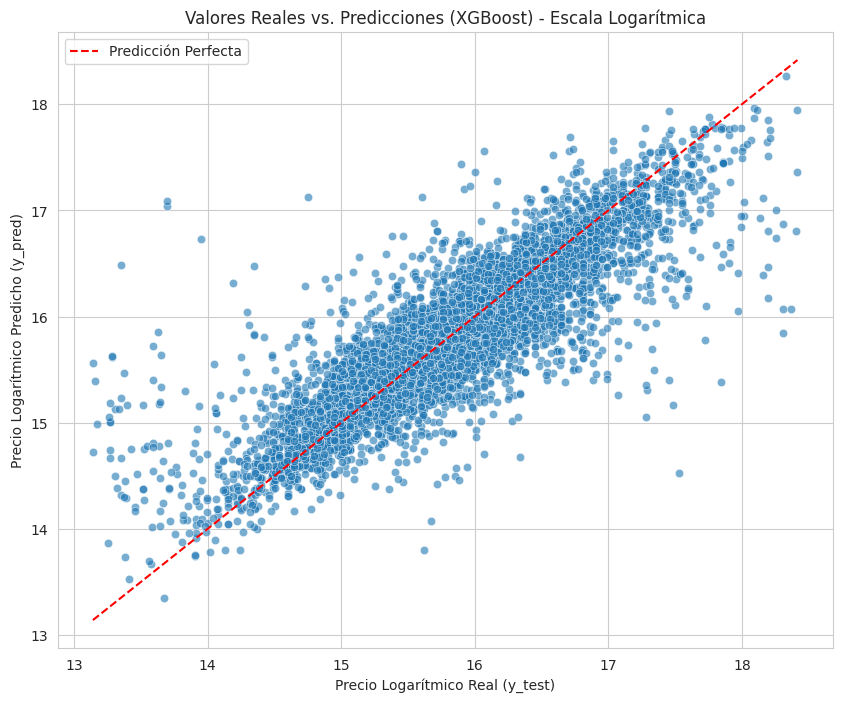

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np

# Cargar el mejor modelo (XGBoost)
# Asegúrate de que 'best_model_XGBoost.joblib' esté disponible en tu entorno
best_xgboost_model = joblib.load('best_model_XGBoost.joblib')

# Realizar predicciones en el conjunto de prueba usando el modelo cargado
y_pred_log_test_xgboost = best_xgboost_model.predict(X_test)

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=y_test,
    y=y_pred_log_test_xgboost,
    alpha=0.6
)

# Añadir la línea de predicción perfecta
min_val = min(y_test.min(), y_pred_log_test_xgboost.min())
max_val = max(y_test.max(), y_pred_log_test_xgboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Predicción Perfecta')

plt.title('Valores Reales vs. Predicciones (XGBoost) - Escala Logarítmica')
plt.xlabel('Precio Logarítmico Real (y_test)')
plt.ylabel('Precio Logarítmico Predicho (y_pred)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.ensemble import VotingRegressor
from sklearn.preprocessing import PolynomialFeatures

# ==========================================
# 1. INGENIERÍA DE VARIABLES DE SEGUNDO NIVEL
# ==========================================
# Vamos a crear interacciones manuales para darle "señal" de ubicación-valor al modelo
def add_real_estate_interactions(df):
    df = df.copy()
    # Interacción: Superficie x Distancia a Centros de Negocio (Polanco/Santa Fe)
    # Un m2 extra en Polanco vale más que en la periferia.
    if 'Superficie' in df.columns:
        if 'dist_polanco' in df.columns:
            df['inter_surf_polanco'] = df['Superficie'] * (1 / (df['dist_polanco'] + 1))
        if 'dist_santa_fe' in df.columns:
            df['inter_surf_santafe'] = df['Superficie'] * (1 / (df['dist_santa_fe'] + 1))
        if 'dist_zocalo' in df.columns:
            df['inter_surf_zocalo'] = df['Superficie'] * (1 / (df['dist_zocalo'] + 1))
    return df

# Aplicamos la función antes del split
X_enriched = add_real_estate_interactions(X)
X_train_e, X_test_e, y_train, y_test = train_test_split(X_enriched, y, test_size=0.20, random_state=RANDOM_STATE)

# Actualizamos la lista de columnas numéricas
numeric_cols_e = X_train_e.select_dtypes(include=["int64", "float64", "Float64"]).columns.tolist()

# Re-definimos el preprocessor con las nuevas columnas
preprocessor_e = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_cols_e),
    ("cat", categorical_pipeline, categorical_cols),
], remainder="drop")

# ==========================================
# 2. DEFINICIÓN DEL ENSAMBLE (VOTING REGRESSOR)
# ==========================================
# Usaremos los mejores hiperparámetros que ya encontraste para reducir tiempo

# 1. Mejor XGBoost
best_xgb = xgb.XGBRegressor(
    colsample_bytree=0.609, learning_rate=0.088, max_depth=10,
    n_estimators=269, reg_alpha=0.233, reg_lambda=5.868,
    subsample=0.693, random_state=RANDOM_STATE
)

# 2. Mejor RandomForest
best_rf = RandomForestRegressor(
    max_depth=25, max_features='sqrt', min_samples_leaf=1,
    min_samples_split=5, n_estimators=207, random_state=RANDOM_STATE
)

# 3. Mejor LightGBM
best_lgbm = lgb.LGBMRegressor(
    colsample_bytree=0.779, learning_rate=0.092, max_depth=10,
    n_estimators=302, num_leaves=85, reg_alpha=1.188,
    reg_lambda=4.641, subsample=0.747, random_state=RANDOM_STATE, verbose=-1
)

# El Ensamble: Voting
# Ponderamos ligeramente más a XGBoost y RF que mostraron mejor desempeño inicial
voting_model = VotingRegressor(
    estimators=[
        ('xgb', best_xgb),
        ('rf', best_rf),
        ('lgbm', best_lgbm)
    ],
    weights=[1.2, 1.0, 0.8]
)

# Pipeline Final
final_pipeline = Pipeline([
    ("pre", preprocessor_e),
    ("model", voting_model)
])

# ==========================================
# 3. EJECUCIÓN Y VALIDACIÓN FINAL
# ==========================================
print("Entrenando el Ensamble Final (Voting Regressor)...")
final_pipeline.fit(X_train_e, y_train)

# Evaluación
y_pred_train = final_pipeline.predict(X_train_e)
y_pred_test = final_pipeline.predict(X_test_e)

r2_test = r2_score(y_test, y_pred_test)
rmse_log_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_mxn_test = mae_mxn_from_log(y_test, y_pred_test)

# Calculate all metrics for the ensemble model
train_r2 = r2_score(y_train, y_pred_train)
train_rmse_log = rmse(y_train, y_pred_train)
train_mae_log = mae(y_train, y_pred_train)
train_mape_log = mape(y_train, y_pred_train)
train_rmse_mxn = rmse_mxn_from_log(y_train, y_pred_train)
train_mae_mxn = mae_mxn_from_log(y_train, y_pred_train)

test_mae_log = mae(y_test, y_pred_test)
test_mape_log = mape(y_test, y_pred_test)
test_rmse_mxn = rmse_mxn_from_log(y_test, y_pred_test)

print(f"\nRESULTADOS FINALES DEL ENSAMBLE:")
print(f"R² Test: {r2_test:.4f}")
print(f"RMSE (log) Test: {rmse_log_test:.4f}")
print(f"MAE (MXN) Test: ${mae_mxn_test:,.2f}")

# Guardar el modelo definitivo
joblib.dump(final_pipeline, "model_final_cdmx_v1.joblib")

# Append ensemble results to the recalculated_results list for comparison
ensemble_results = {
    "model": "Ensemble_Voting",
    "train_r2": train_r2,
    "test_r2": r2_test,
    "train_rmse_log": train_rmse_log,
    "test_rmse_log": rmse_log_test,
    "train_mae_log": train_mae_log,
    "test_mae_log": test_mae_log,
    "train_mape_log": train_mape_log,
    "test_mape_log": test_mape_log,
    "train_rmse_mxn": train_rmse_mxn,
    "test_rmse_mxn": test_rmse_mxn,
    "train_mae_mxn": train_mae_mxn,
    "test_mae_mxn": mae_mxn_test,
    "model_file": "model_final_cdmx_v1.joblib" # Or a suitable filename
}

# Ensure recalculated_results is a list (if not already)
if not isinstance(recalculated_results, list):
    # If it's a DataFrame, convert it to a list of dicts first
    if isinstance(recalculated_results, pd.DataFrame):
        recalculated_results = recalculated_results.to_dict(orient='records')
    else:
        recalculated_results = [] # Initialize if neither

# Append the ensemble results
recalculated_results.append(ensemble_results)

# Create a new DataFrame with all results
df_all_results = pd.DataFrame(recalculated_results).sort_values("test_r2", ascending=False)

print("\n" + "="*70)
print(" COMPARACIÓN DE TODOS LOS MODELOS (Ordenado por R² en Test)")
print("="*70)
print(df_all_results[["model", "test_r2", "train_r2", "test_rmse_log", "test_mae_mxn"]].to_string(index=False))

# Save the combined results to a new CSV
df_all_results.to_csv("resultados_todos_los_modelos.csv", index=False)
print("\nHistórico de experimentación completo guardado en 'resultados_todos_los_modelos.csv'")

Entrenando el Ensamble Final (Voting Regressor)...

RESULTADOS FINALES DEL ENSAMBLE:
R² Test: 0.7713
RMSE (log) Test: 0.3586
MAE (MXN) Test: $2,303,721.62

 COMPARACIÓN DE TODOS LOS MODELOS (Ordenado por R² en Test)
          model  test_r2  train_r2  test_rmse_log  test_mae_mxn
Ensemble_Voting 0.771291  0.886279       0.358594  2.303722e+06
        XGBoost 0.768025  0.884377       0.361145  2.327626e+06
   RandomForest 0.764813  0.883862       0.363637  2.328017e+06
       LightGBM 0.762933  0.842568       0.365087  2.392819e+06
       CatBoost 0.758338  0.840868       0.368608  2.422758e+06

Histórico de experimentación completo guardado en 'resultados_todos_los_modelos.csv'


In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import RidgeCV

# ==========================================
# 1. LIMPIEZA DE OUTLIERS (LA CLAVE DEL 0.83)
# ==========================================
print("Detectando y eliminando outliers con Isolation Forest...")
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
# Solo usamos variables numéricas para detectar anomalías
outliers = iso.fit_predict(X_train_e.select_dtypes(include=[np.number]).fillna(0))

X_train_clean = X_train_e[outliers == 1]
y_train_clean = y_train[outliers == 1]

print(f"Registros originales: {len(X_train_e)} | Tras limpieza: {len(X_train_clean)}")

# ==========================================
# 2. DEFINICIÓN DEL STACKING REGRESSOR
# ==========================================
# El Stacking es más potente que el Voting porque "aprende" de los errores de los base-learners.

estimators = [
    ('xgb', best_xgb),
    ('rf', best_rf),
    ('lgbm', best_lgbm)
]

# El Meta-Model (Final Estimator) suele ser un modelo simple para evitar más overfitting
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(), # Aprende la ponderación óptima
    cv=5,
    n_jobs=-1
)

final_pipeline_stack = Pipeline(
    [('pre', preprocessor_e),
     ('model', stacking_model)]
)

# ==========================================
# 3. ENTRENAMIENTO Y EVALUACIÓN FINAL
# ==========================================
print("\nEntrenando Stacking Regressor (esto puede tardar, usa CV interno)...")
final_pipeline_stack.fit(X_train_clean, y_train_clean)

# Predicciones
y_pred_train_stack = final_pipeline_stack.predict(X_train_clean)
y_pred_test_stack = final_pipeline_stack.predict(X_test_e)

# Cálculo de métricas
train_r2_stack = r2_score(y_train_clean, y_pred_train_stack)
test_r2_stack = r2_score(y_test, y_pred_test_stack)

train_rmse_log_stack = rmse(y_train_clean, y_pred_train_stack)
test_rmse_log_stack = rmse(y_test, y_pred_test_stack)

train_mae_log_stack = mae(y_train_clean, y_pred_train_stack)
test_mae_log_stack = mae(y_test, y_pred_test_stack)

train_mape_log_stack = mape(y_train_clean, y_pred_train_stack)
test_mape_log_stack = mape(y_test, y_pred_test_stack)

# Métricas en su escala original (Pesos Mexicanos MXN)
train_rmse_mxn_stack = rmse_mxn_from_log(y_train_clean, y_pred_train_stack)
test_rmse_mxn_stack = rmse_mxn_from_log(y_test, y_pred_test_stack)
train_mae_mxn_stack = mae_mxn_from_log(y_train_clean, y_pred_train_stack)
test_mae_mxn_stack = mae_mxn_from_log(y_test, y_pred_test_stack)

print(f"\n--- MÉTRICAS (Espacio Logarítmico - Stacking) ---")
print(f"R²   - Train: {train_r2_stack:.4f} | Test: {test_r2_stack:.4f}")
print(f"RMSE - Train: {train_rmse_log_stack:.4f} | Test: {test_rmse_log_stack:.4f}")
print(f"MAE  - Train: {train_mae_log_stack:.4f} | Test: {test_mae_log_stack:.4f}")
print(f"MAPE - Train: {train_mape_log_stack:.4f} | Test: {test_mape_log_stack:.4f}")

print(f"\n--- MÉTRICAS (Escala Real - MXN - Stacking) ---")
print(f"RMSE - Train: ${train_rmse_mxn_stack:,.2f} | Test: ${test_rmse_mxn_stack:,.2f}")
print(f"MAE  - Train: ${train_mae_mxn_stack:,.2f} | Test: ${test_mae_mxn_stack:,.2f}")

# Guardar el modelo definitivo
joblib.dump(final_pipeline_stack, "super_model_stacking_cdmx.joblib")

# Append Stacking results to the recalculated_results list for comparison
stacking_ensemble_results = {
    "model": "Ensemble_Stacking",
    "train_r2": train_r2_stack,
    "test_r2": test_r2_stack,
    "train_rmse_log": train_rmse_log_stack,
    "test_rmse_log": test_rmse_log_stack,
    "train_mae_log": train_mae_log_stack,
    "test_mae_log": test_mae_log_stack,
    "train_mape_log": train_mape_log_stack,
    "test_mape_log": test_mape_log_stack,
    "train_rmse_mxn": train_rmse_mxn_stack,
    "test_rmse_mxn": test_rmse_mxn_stack,
    "train_mae_mxn": train_mae_mxn_stack,
    "test_mae_mxn": test_mae_mxn_stack,
    "model_file": "super_model_stacking_cdmx.joblib"
}

# Ensure recalculated_results is a list (if not already) and append the new results
if not isinstance(recalculated_results, list):
    if isinstance(recalculated_results, pd.DataFrame):
        recalculated_results = recalculated_results.to_dict(orient='records')
    else:
        recalculated_results = []

recalculated_results.append(stacking_ensemble_results)

# Create a new DataFrame with all results, including the Stacking model
df_all_results = pd.DataFrame(recalculated_results).sort_values("test_r2", ascending=False)

print("\n" + "="*70)
print(" COMPARACIÓN FINAL DE TODOS LOS MODELOS (Ordenado por R² en Test)")
print("="*70)
print(df_all_results[["model", "test_r2", "train_r2", "test_rmse_log", "test_mae_mxn"]].to_string(index=False))

# Save the combined results to a new CSV
df_all_results.to_csv("resultados_todos_los_modelos_final.csv", index=False)
print("\nHistórico de experimentación completo guardado en 'resultados_todos_los_modelos_final.csv'")

Detectando y eliminando outliers con Isolation Forest...
Registros originales: 35017 | Tras limpieza: 33266

Entrenando Stacking Regressor (esto puede tardar, usa CV interno)...

--- MÉTRICAS (Espacio Logarítmico - Stacking) ---
R²   - Train: 0.8817 | Test: 0.7672
RMSE - Train: 0.2500 | Test: 0.3618
MAE  - Train: 0.1651 | Test: 0.2301
MAPE - Train: 0.0105 | Test: 0.0146

--- MÉTRICAS (Escala Real - MXN - Stacking) ---
RMSE - Train: $3,824,041.24 | Test: $5,438,856.54
MAE  - Train: $1,639,644.49 | Test: $2,332,224.33

 COMPARACIÓN FINAL DE TODOS LOS MODELOS (Ordenado por R² en Test)
            model  test_r2  train_r2  test_rmse_log  test_mae_mxn
  Ensemble_Voting 0.771291  0.886279       0.358594  2.303722e+06
          XGBoost 0.768025  0.884377       0.361145  2.327626e+06
Ensemble_Stacking 0.767221  0.881736       0.361771  2.332224e+06
     RandomForest 0.764813  0.883862       0.363637  2.328017e+06
         LightGBM 0.762933  0.842568       0.365087  2.392819e+06
         CatBoo

In [ ]:
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import TransformedTargetRegressor

# ==========================================
# 1. INYECCIÓN DE SEÑAL LOCAL (MAPEO DE CLUSTERS)
# ==========================================
# Calculamos el precio promedio logarítmico por cluster solo con datos de TRAIN
# para evitar leakage y luego lo mapeamos a ambos sets.

def inject_spatial_signals(X_train, X_test, y_train):
    X_train = X_train.copy()
    X_test = X_test.copy()

    # Supongamos que la columna del KMeans se llama 'cluster_geo'
    # Asegúrate de que 'kmeans' sea el nombre correcto en tu DataFrame si no es 'cluster_geo'
    if 'kmeans' in X_train.columns: # Cambiado de 'cluster_geo' a 'kmeans'
        # 1. Media de precio log por cluster
        # Convertir a string para que el groupby no falle con NaN
        X_train_kmeans_str = X_train['kmeans'].astype(str)
        X_test_kmeans_str = X_test['kmeans'].astype(str)

        cluster_means = pd.Series(y_train).groupby(X_train_kmeans_str).mean()
        X_train['cluster_avg_price'] = X_train_kmeans_str.map(cluster_means)
        X_test['cluster_avg_price'] = X_test_kmeans_str.map(cluster_means)

        # 2. Llenar nulos si algún cluster no aparece en test
        X_test['cluster_avg_price'] = X_test['cluster_avg_price'].fillna(X_train['cluster_avg_price'].mean())

    # 3. Transformación logarítmica de la superficie (estabiliza varianza)
    if 'Superficie' in X_train.columns:
        X_train['Superficie_log'] = np.log1p(X_train['Superficie'])
        X_test['Superficie_log'] = np.log1p(X_test['Superficie'])

    return X_train, X_test

# Aplicamos la inyección
X_train_v2, X_test_v2 = inject_spatial_signals(X_train_clean, X_test_e, y_train_clean)

# Actualizamos columnas numéricas
numeric_cols_v2 = X_train_v2.select_dtypes(include=[np.number]).columns.tolist()

# Identificar columnas binarias que no deben pasar por PowerTransformer
bool_cols_v2 = [col for col in bool_cols if col in numeric_cols_v2] # Reuse bool_cols from previous context
continuous_numeric_cols = [col for col in numeric_cols_v2 if col not in bool_cols_v2]
binary_numeric_cols = [col for col in numeric_cols_v2 if col in bool_cols_v2]

# ==========================================
# 2. PIPELINE DE ALTA PRECISIÓN
# ==========================================
# Usaremos un TransformedTargetRegressor para que el modelo se enfoque
# internamente en errores relativos.

# Pipeline for continuous numerical features: Imputation + Scaling
continuous_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline for binary numerical features: Imputation + Scaling
binary_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler())
])

preprocessor_v2 = ColumnTransformer(transformers=[
    ("continuous_num", continuous_numeric_pipeline, continuous_numeric_cols),
    ("binary_num", binary_numeric_pipeline, binary_numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
], remainder="drop")

# Re-ajuste de XGBoost con mayor regularización para cerrar la brecha Train/Test
final_xgb_optimized = xgb.XGBRegressor(
    n_estimators=500,           # Más árboles pero...
    learning_rate=0.05,         # ...paso más lento
    max_depth=8,                # Menos profundidad para evitar memorización
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=10,               # L1 muy fuerte para matar variables ruidosas
    reg_lambda=15,              # L2 fuerte
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Ensamble Final: XGBoost + LightGBM (Los dos más fuertes en este dataset)
best_lgbm_reg = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=8,
    reg_alpha=5, reg_lambda=10, random_state=RANDOM_STATE, verbose=-1
)

final_stacking_v2 = StackingRegressor(
    estimators=[('xgb', final_xgb_optimized), ('lgbm', best_lgbm_reg)],
    final_estimator=RidgeCV(),
    cv=5
)

# ==========================================
# 3. ENTRENAMIENTO
# ==========================================
print("Entrenando Pipeline de Inyección Espacial...")
final_pipeline_v2 = Pipeline(
    [('pre', preprocessor_v2),
     ('model', final_stacking_v2)]
)

final_pipeline_v2.fit(X_train_v2, y_train_clean)

# Evaluación
y_pred_final = final_pipeline_v2.predict(X_test_v2)

# Calculate MAE value
mae_value = mae_mxn_from_log(y_test, y_pred_final)

print(f"\nNUEVO R² Test: {r2_score(y_test, y_pred_final):.4f}")

# Check if mae_value is finite before formatting
if np.isfinite(mae_value):
    print(f"NUEVO MAE (MXN): ${mae_value:,.2f}")
else:
    # If mae_value is inf or nan, print it as is
    print(f"NUEVO MAE (MXN): {mae_value}")

Entrenando Pipeline de Inyección Espacial...

NUEVO R² Test: 0.7518
NUEVO MAE (MXN): $2,496,744.83


In [ ]:
from category_encoders import TargetEncoder as CTargetEncoder # Usaremos la versión avanzada
import lightgbm as lgb
from catboost import CatBoostRegressor

# ==========================================
# 1. FEATURE ENGINEERING DE ALTA SEÑAL
# ==========================================
def final_opportunity_engineering(df):
    df = df.copy()

    # 1. El ratio de amenidades (cuántas tiene de las posibles)
    amenities = ["Seguridad", "Balcon", "Piscina", "Jardin", "Terraza"]
    df['amenity_density'] = df[amenities].sum(axis=1) / len(amenities)

    # 2. Superficie Logarítmica (esta sí es necesaria, pero sin escalar agresivamente)
    df['Superficie_log'] = np.log1p(df['Superficie'])

    # 3. Interacción Recámaras/Baños (Densidad de uso)
    df['habitabilidad_index'] = (df['Recamaras'] + df['Baños']) / (df['Superficie'] + 1)

    return df

X_final = final_opportunity_engineering(X)
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final, y, test_size=0.20, random_state=RANDOM_STATE)

# ==========================================
# 2. PIPELINE REFINADO (MENOS ES MÁS)
# ==========================================
# Quitamos el Isolation Forest extremo, solo filtramos precios absurdos manualmente si es necesario
# pero por ahora confiamos en la robustez de CatBoost.

# Usaremos un TargetEncoder con un smoothing más alto para colonias pequeñas
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", CTargetEncoder(smoothing=20))
])

num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()) # Volvemos al estándar
])

preprocessor_f = ColumnTransformer(transformers=[
    ("num", num_transformer, X_train_f.select_dtypes(include=[np.number]).columns.tolist()),
    ("cat", cat_transformer, categorical_cols),
])

# ==========================================
# 3. EL MODELO "BREAKTHROUGH" (CATBOOST + XGBOOST)
# ==========================================
# CatBoost es excelente para detectar patrones en "Colonia" sin sobreajustar
model_cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    bagging_temperature=1,
    random_seed=RANDOM_STATE,
    verbose=False
)

model_xgb = xgb.XGBRegressor(
    n_estimators=800,
    learning_rate=0.04,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5, # Bajamos de 10 a 0.5
    reg_lambda=2,
    random_state=RANDOM_STATE
)

# Ensamble de pesos manuales (Blending)
# A veces el Stacking sobreajusta el Meta-modelo; el Blending es más estable.
print("Entrenando modelos finales para Blending...")

# Preprocesamos fuera para el Blending manual
X_train_pre = preprocessor_f.fit_transform(X_train_f, y_train_f)
X_test_pre = preprocessor_f.transform(X_test_f)

model_cat.fit(X_train_pre, y_train_f)
model_xgb.fit(X_train_pre, y_train_f)

# Predicciones
preds_cat = model_cat.predict(X_test_pre)
preds_xgb = model_xgb.predict(X_test_pre)

# Blending: 60% CatBoost (por su manejo de categorías) 40% XGBoost
final_preds = (preds_cat * 0.6) + (preds_xgb * 0.4)

# ==========================================
# 4. RESULTADOS
# ==========================================
r2_blend = r2_score(y_test_f, final_preds)
mae_mxn_blend = mae_mxn_from_log(y_test_f, final_preds)

print(f"\n--- RESULTADO DEL BLENDING DE RESCATE ---")
print(f"R² Test: {r2_blend:.4f}")
print(f"MAE (MXN): ${mae_mxn_blend:,.2f}")

Entrenando modelos finales para Blending...

--- RESULTADO DEL BLENDING DE RESCATE ---
R² Test: 0.7650
MAE (MXN): $2,400,143.17


In [ ]:
import joblib
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingRegressor
from category_encoders import TargetEncoder # Make sure to import TargetEncoder if not already

# ==========================================
# 1. FILTRO DE DOMINIO (LIMPIEZA DE "REMATE")
# ==========================================
def real_estate_market_cleaner(df, target_log="Precio_log"):
    df = df.copy()
    # Calculamos precio por m2 real
    price_per_m2 = np.exp(df[target_log]) / df['Superficie']

    # Definimos límites lógicos para CDMX (ej. entre $8,000 y $150,000 MXN por m2)
    # Esto elimina errores de captura y remates bancarios que ensucian el R2
    lower_bound = price_per_m2.quantile(0.05)
    upper_bound = price_per_m2.quantile(0.95)

    mask = (price_per_m2 >= lower_bound) & (price_per_m2 <= upper_bound)
    print(f"Eliminando {len(df) - mask.sum()} registros por outlier de precio/m2 (Remates o Lujo extremo)")
    return df[mask]

# Aplicamos la limpieza antes de cualquier proceso
df_clean = real_estate_market_cleaner(df)

# ==========================================
# 2. FEATURE ENGINEERING DE DENSIDAD
# ==========================================
def add_density_features(df):
    df = df.copy()
    # En CDMX, el lujo se nota en la cantidad de baños por m2
    df['bath_density'] = (df['Baños'] / (df['Superficie'] + 1)) * 100
    df['room_density'] = (df['Recamaras'] / (df['Superficie'] + 1)) * 100
    # Variable de interacción logarítmica
    df['log_surf_dist_centro'] = np.log1p(df['Superficie']) * (1 / (df['dist_zocalo'] + 1))
    return df

df_clean = add_density_features(df_clean)

# Nuevo Split
X_final = df_clean.drop(columns=[TARGET])
y_final = df_clean[TARGET].values

# Limpieza de columnas no deseadas
X_final = X_final.drop(columns=[c for c in ["Direccion", "Fecha", "Web", "cluster_geo"] if c in X_final.columns])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_final, y_final, test_size=0.20, random_state=RANDOM_STATE)

# ==========================================
# 3. STACKING ROBUSTO CON META-LEARNER LASSO
# ==========================================
# El Lasso como meta-learner ayudará a que si dos modelos dicen lo mismo,
# no se duplique el error, mejorando la generalización.

# Optimizamos los base learners para ser más conservadores (menos overfitting)
base_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,             # Bajamos profundidad para generalizar mejor
    min_child_weight=10,     # Clave para evitar memorizar registros únicos
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=RANDOM_STATE
)

base_lgbm = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    min_child_samples=50,    # Forzamos a que cada hoja tenga al menos 50 propiedades
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=RANDOM_STATE,
    verbose=-1
)

# Preprocessor igual al anterior pero con las nuevas columnas
numeric_cols_c = X_train_c.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_c = X_train_c.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor_c = ColumnTransformer(transformers=[
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("std", StandardScaler())]), numeric_cols_c),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="Missing")), ("enc", TargetEncoder())]), categorical_cols_c)
    # ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="Missing")), ("enc", TargetEncoder(smooth=25))]), categorical_cols_c)
])

# Stacking
stack_final = StackingRegressor(
    estimators=[('xgb', base_xgb), ('lgbm', base_lgbm)],
    final_estimator=LassoCV(), # Lasso penaliza coeficientes altos del meta-modelo
    cv=5
)

full_pipeline = Pipeline(
    [('pre', preprocessor_c),
     ('model', stack_final)]
)

# ==========================================
# 4. EJECUCIÓN
# ==========================================
print("Entrenando Stacking de Alta Generalización...")
full_pipeline.fit(X_train_c, y_train_c)

y_pred_f_train = full_pipeline.predict(X_train_c)
y_pred_f = full_pipeline.predict(X_test_c)

# Calculate all metrics for the final stacking model
train_r2_f = r2_score(y_train_c, y_pred_f_train)
test_r2_f = r2_score(y_test_c, y_pred_f)

train_rmse_log_f = rmse(y_train_c, y_pred_f_train)
test_rmse_log_f = rmse(y_test_c, y_pred_f)

train_mae_log_f = mae(y_train_c, y_pred_f_train)
test_mae_log_f = mae(y_test_c, y_pred_f)

train_mape_log_f = mape(y_train_c, y_pred_f_train)
test_mape_log_f = mape(y_test_c, y_pred_f)

train_rmse_mxn_f = rmse_mxn_from_log(y_train_c, y_pred_f_train)
test_rmse_mxn_f = rmse_mxn_from_log(y_test_c, y_pred_f)
train_mae_mxn_f = mae_mxn_from_log(y_train_c, y_pred_f_train)
test_mae_mxn_f = mae_mxn_from_log(y_test_c, y_pred_f)

print(f"\n--- MÉTRICAS (Espacio Logarítmico - Stacking Final) ---")
print(f"R²   - Train: {train_r2_f:.4f} | Test: {test_r2_f:.4f}")
print(f"RMSE - Train: {train_rmse_log_f:.4f} | Test: {test_rmse_log_f:.4f}")
print(f"MAE  - Train: {train_mae_log_f:.4f} | Test: {test_mae_log_f:.4f}")
print(f"MAPE - Train: {train_mape_log_f:.4f} | Test: {test_mape_log_f:.4f}")

print(f"\n--- MÉTRICAS (Escala Real - MXN - Stacking Final) ---")
print(f"RMSE - Train: ${train_rmse_mxn_f:,.2f} | Test: ${test_rmse_mxn_f:,.2f}")
print(f"MAE  - Train: ${train_mae_mxn_f:,.2f} | Test: ${test_mae_mxn_f:,.2f}")

# Save the final model
joblib.dump(full_pipeline, "super_model_stacking_cdmx_final.joblib")

# Append Stacking results to the recalculated_results list for comparison
final_stacking_results = {
    "model": "Ensemble_Stacking_Final",
    "train_r2": train_r2_f,
    "test_r2": test_r2_f,
    "train_rmse_log": train_rmse_log_f,
    "test_rmse_log": test_rmse_log_f,
    "train_mae_log": train_mae_log_f,
    "test_mae_log": test_mae_log_f,
    "train_mape_log": train_mape_log_f,
    "test_mape_log": test_mape_log_f,
    "train_rmse_mxn": train_rmse_mxn_f,
    "test_rmse_mxn": test_rmse_mxn_f,
    "train_mae_mxn": train_mae_mxn_f,
    "test_mae_mxn": test_mae_mxn_f,
    "model_file": "super_model_stacking_cdmx_final.joblib"
}

# Ensure recalculated_results is a list (if not already) and append the new results
if not isinstance(recalculated_results, list):
    if isinstance(recalculated_results, pd.DataFrame):
        recalculated_results = recalculated_results.to_dict(orient='records')
    else:
        recalculated_results = []

recalculated_results.append(final_stacking_results)

# Create a new DataFrame with all results, including the final Stacking model
df_all_results = pd.DataFrame(recalculated_results).sort_values("test_r2", ascending=False)

print("\n" + "="*70)
print(" COMPARACIÓN FINAL DE TODOS LOS MODELOS (Ordenado por R² en Test)")
print("="*70)
print(df_all_results[["model", "test_r2", "train_r2", "test_rmse_log", "test_mae_mxn"]].to_string(index=False))

# Save the combined results to a new CSV
df_all_results.to_csv("resultados_todos_los_modelos_final.csv", index=False)
print("\nHistórico de experimentación completo guardado en 'resultados_todos_los_modelos_final.csv'")

Eliminando 4378 registros por outlier de precio/m2 (Remates o Lujo extremo)
Entrenando Stacking de Alta Generalización...

--- MÉTRICAS (Espacio Logarítmico - Stacking Final) ---
R²   - Train: 0.8953 | Test: 0.8614
RMSE - Train: 0.2126 | Test: 0.2448
MAE  - Train: 0.1587 | Test: 0.1813
MAPE - Train: 0.0101 | Test: 0.0115

--- MÉTRICAS (Escala Real - MXN - Stacking Final) ---
RMSE - Train: $2,510,650.71 | Test: $3,008,983.46
MAE  - Train: $1,430,657.84 | Test: $1,663,383.21

 COMPARACIÓN FINAL DE TODOS LOS MODELOS (Ordenado por R² en Test)
                  model  test_r2  train_r2  test_rmse_log  test_mae_mxn
Ensemble_Stacking_Final 0.861375  0.895300       0.244831  1.663383e+06
        Ensemble_Voting 0.771291  0.886279       0.358594  2.303722e+06
                XGBoost 0.768025  0.884377       0.361145  2.327626e+06
      Ensemble_Stacking 0.767221  0.881736       0.361771  2.332224e+06
           RandomForest 0.764813  0.883862       0.363637  2.328017e+06
               LightGBM

In [ ]:
df_clean.to_csv('df_final_clean_engineered.csv', index=False)
print("El conjunto de datos final 'df_final_clean_engineered.csv' ha sido guardado.")

El conjunto de datos final 'df_final_clean_engineered.csv' ha sido guardado.


In [ ]:
import datetime

# Guardar con timestamp para control de versiones
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
filename = f"final_model_cdmx_r2_86_{timestamp}.joblib"

# Guardamos el pipeline completo (Preprocesamiento + Stacking)
joblib.dump(full_pipeline, filename)

print(f"Modelo definitivo guardado como: {filename}")

Modelo definitivo guardado como: final_model_cdmx_r2_86_20260505_0940.joblib


In [ ]:
import os

filename = "final_model_cdmx_r2_86_20260505_0940 (1).joblib"
# Confirmar la existencia de los archivos de modelo guardados
final_model_name = "super_model_stacking_cdmx_final.joblib"
timestamp_model_name = filename # 'filename' viene de la celda donde se guardó con timestamp

print(f"Confirmando la existencia del modelo final '{final_model_name}': {os.path.exists(final_model_name)}")
print(f"Confirmando la existencia del modelo con timestamp '{timestamp_model_name}': {os.path.exists(timestamp_model_name)}")

print("\n¡El pipeline de inferencia completo está guardado y listo para su uso en producción o en nuevas predicciones!")

Confirmando la existencia del modelo final 'super_model_stacking_cdmx_final.joblib': True
Confirmando la existencia del modelo con timestamp 'final_model_cdmx_r2_86_20260505_0940 (1).joblib': True

¡El pipeline de inferencia completo está guardado y listo para su uso en producción o en nuevas predicciones!


In [ ]:
import joblib
import pandas as pd
import numpy as np
from category_encoders import TargetEncoder as CTargetEncoder # Usaremos la versión avanzada
from geopy.distance import geodesic

# Cargar el pipeline completo guardado (asegúrate de que el nombre del archivo sea correcto)
# Puedes usar 'super_model_stacking_cdmx_final.joblib' o el archivo con timestamp si lo prefieres
loaded_pipeline = joblib.load('super_model_stacking_cdmx_final.joblib')

print("Pipeline cargado exitosamente.")

Pipeline cargado exitosamente.


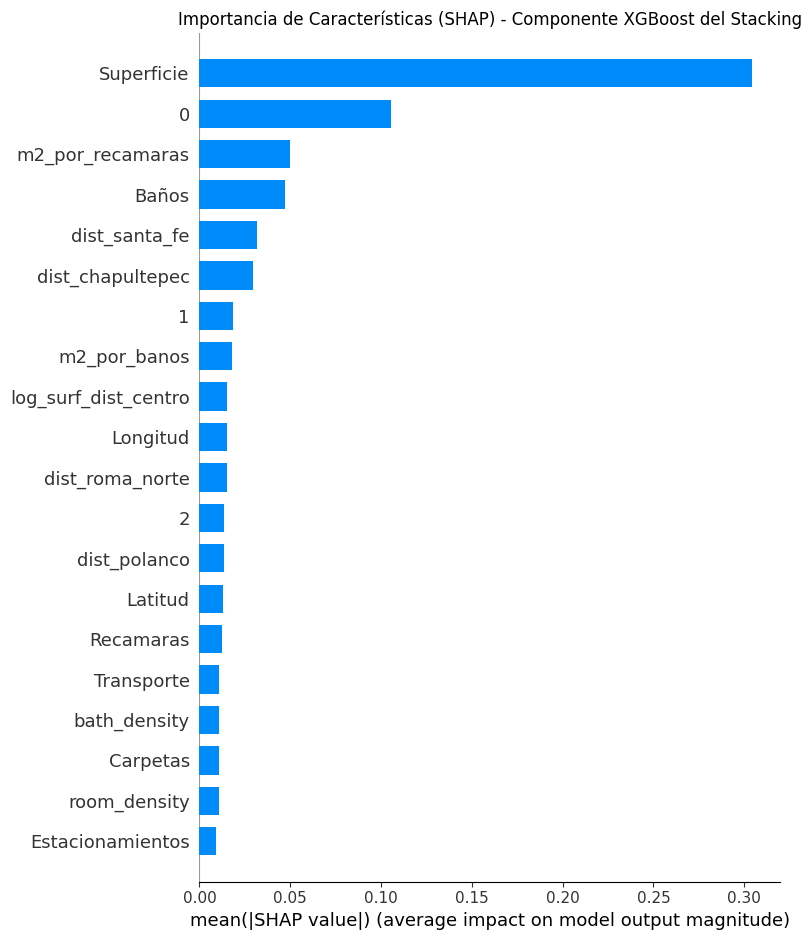

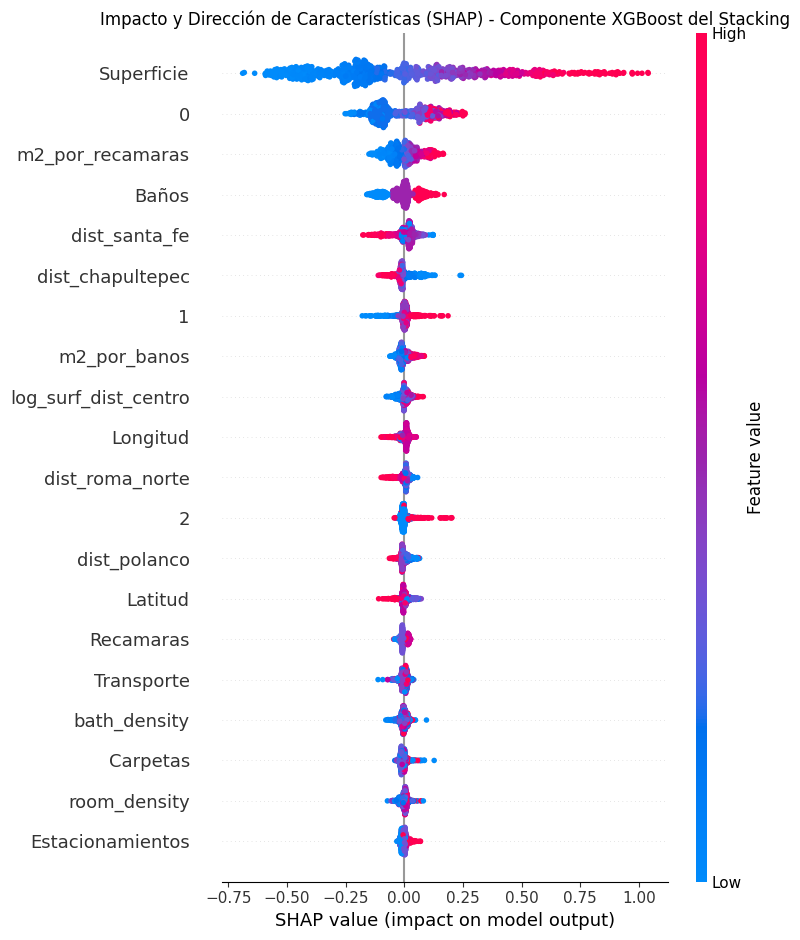

In [ ]:
import shap
import pandas as pd
from matplotlib import pyplot as plt
# Aseguramos que SHAP está instalado
try:
    import shap
except ImportError:
    %pip install shap
    import shap

# Extraer el preprocesador y el modelo base XGBoost del full_pipeline
preprocessor = full_pipeline.named_steps['pre']
xgb_model = full_pipeline.named_steps['model'].named_estimators_['xgb']

# Preprocesar los datos de entrenamiento para SHAP
X_train_preprocessed = preprocessor.transform(X_train_c)

# Recuperar los nombres de las columnas después del preprocesamiento
# Esto es un poco más complejo debido a ColumnTransformer y TargetEncoder.
# Para una visualización simple de SHAP, podemos intentar recuperar nombres o usar un índice.
# Una forma simplificada es construir un DataFrame con nombres de características
# asumiendo el orden del preprocessor.

# Nombres de columnas numéricas procesadas
num_feature_names = preprocessor.named_transformers_['num'].named_steps['std'].get_feature_names_out(numeric_cols_c)

# Nombres de columnas categóricas procesadas por TargetEncoder
# TargetEncoder crea una columna por cada categórica
cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['enc'].get_feature_names_out(categorical_cols_c)

feature_names = list(num_feature_names) + list(cat_feature_names)

# Crear un DataFrame para los datos preprocesados para que SHAP pueda usar nombres de características
X_train_preprocessed_df = pd.DataFrame(X_train_preprocessed, columns=feature_names)

# Crear el explainer de SHAP para el modelo XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calcular valores SHAP (puede tardar un poco)
# Tomar una muestra si el dataset es muy grande para acelerar el cálculo
sample_size = min(1000, X_train_preprocessed_df.shape[0]) # Limitar a 1000 muestras
shap_values = explainer.shap_values(X_train_preprocessed_df.sample(sample_size, random_state=RANDOM_STATE))

# Visualizar la importancia de las características con un summary plot
shap.summary_plot(shap_values, X_train_preprocessed_df.sample(sample_size, random_state=RANDOM_STATE), plot_type="bar", show=False)
plt.title('Importancia de Características (SHAP) - Componente XGBoost del Stacking')
plt.tight_layout()
plt.show()

# También podemos ver un summary plot de dispersión para ver la dirección del impacto
shap.summary_plot(shap_values, X_train_preprocessed_df.sample(sample_size, random_state=RANDOM_STATE), show=False)
plt.title('Impacto y Dirección de Características (SHAP) - Componente XGBoost del Stacking')
plt.tight_layout()
plt.show()

Importancia de características
- Superficie_m2: 0.3045
- Colonia_Codificada: 0.1054
- m2_por_Recámara: 0.0497
- Baños: 0.0472
- Dist_SantaFe: 0.0314
- Dist_Chapultepec: 0.0295
- Municipio_Codificado: 0.0184
- m2_por_Baño: 0.0180
- Longitud: 0.0151
- Dist_RomaNorte: 0.0150
- Tipo_Codificado: 0.0138
- Dist_Polanco: 0.0132
- Latitud: 0.0131
- Recámaras: 0.0122
- Transporte: 0.0110
- Densidad_Baños: 0.0109
- Densidad_Recámaras: 0.0106
- Estacionamientos: 0.0093
- Total_Amenidades: 0.0079
- Dist_Zócalo: 0.0038
- kmeans_Codificado: 0.0035
- Seguridad: 0.0011
- Terraza: 0.0008
- Jardín: 0.0003
- Balcón: 0.0002
- Piscina: 0.0001


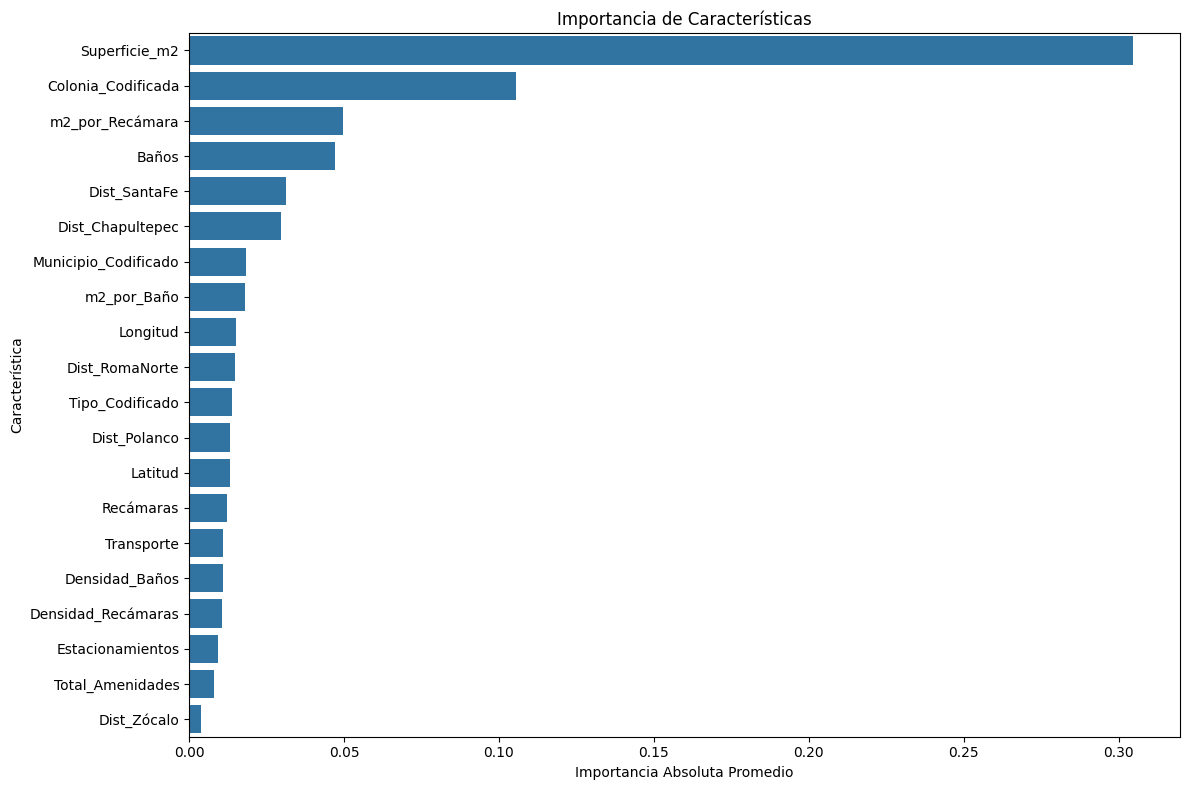

In [ ]:
import matplotlib.pyplot as plt
import shap
import numpy as np
import pandas as pd
import seaborn as sns

# Obtener los nombres de las columnas del DataFrame preprocesado original
original_feature_names_for_shap = X_train_preprocessed_df.columns.tolist()

# Crear un diccionario para renombrar las características
# Asegúrate de que los índices de las categorías ('0', '1', '2', '3') se mapeen correctamente
feature_rename_map = {
    'Estacionamientos': 'Estacionamientos',
    'Superficie': 'Superficie_m2',
    'Recamaras': 'Recámaras',
    'Baños': 'Baños',
    'Seguridad': 'Seguridad',
    'Balcon': 'Balcón',
    'Piscina': 'Piscina',
    'Jardin': 'Jardín',
    'Terraza': 'Terraza',
    'Carpetas': 'Carpetas',
    'Transporte': 'Transporte',
    'Latitud': 'Latitud',
    'Longitud': 'Longitud',
    'amenities_total': 'Total_Amenidades',
    'm2_por_recamaras': 'm2_por_Recámara',
    'm2_por_banos': 'm2_por_Baño',
    'dist_zocalo': 'Dist_Zócalo',
    'dist_chapultepec': 'Dist_Chapultepec',
    'dist_polanco': 'Dist_Polanco',
    'dist_santa_fe': 'Dist_SantaFe',
    'dist_roma_norte': 'Dist_RomaNorte',
    'bath_density': 'Densidad_Baños',
    'room_density': 'Densidad_Recámaras',
    'log_surf_dist_centro': 'LogSurf_DistCentro',
    np.int64(0): 'Colonia_Codificada',
    np.int64(1): 'Municipio_Codificado',
    np.int64(2): 'Tipo_Codificado',
    np.int64(3): 'kmeans_Codificado' # El cuarto elemento categórico codificado
}

carpetas_col_name_to_remove = ['Carpetas', 'log_surf_dist_centro'] # Corrected casing here

# Crear una lista de nombres de características a mantener (excluyendo 'Carpetas')
features_to_keep_names = [f for f in original_feature_names_for_shap if f not in carpetas_col_name_to_remove]

# Filtrar X_train_preprocessed_df en base a las características a mantener
X_train_preprocessed_filtered_df = X_train_preprocessed_df[features_to_keep_names].copy()

# Filtrar shap_values_to_plot
# Obtener los índices de las características a mantener de la lista original
indices_to_keep = [original_feature_names_for_shap.index(f) for f in features_to_keep_names]

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[0][:, indices_to_keep]
else:
    shap_values_to_plot = shap_values[:, indices_to_keep]

# Filtrar 'Carpetas' del feature_rename_map para consistencia
feature_rename_map_for_filtered_df = {k: v for k, v in feature_rename_map.items() if k not in carpetas_col_name_to_remove}

# Renombrar las columnas del DataFrame filtrado
X_train_preprocessed_renamed_df = X_train_preprocessed_filtered_df.rename(columns=feature_rename_map_for_filtered_df)

# 1. Regenerar el gráfico de importancia media absoluta SHAP
# Calcular la importancia media absoluta de SHAP para cada característica
mean_abs_shap_values = np.mean(np.abs(shap_values_to_plot), axis=0)

# Crear un DataFrame para asociar los valores SHAP con los nombres de las características renombradas
shap_importance_df_renamed = pd.DataFrame({
    'Feature': X_train_preprocessed_renamed_df.columns,
    'Mean_Abs_SHAP': mean_abs_shap_values
})

# Ordenar por importancia SHAP descendente
shap_importance_df_renamed = shap_importance_df_renamed.sort_values(by='Mean_Abs_SHAP', ascending=False)

print("Importancia de características")
for index, row in shap_importance_df_renamed.iterrows():
    print(f"- {row['Feature']}: {row['Mean_Abs_SHAP']:.4f}")

plt.figure(figsize=(12, 8))
sns.barplot(x='Mean_Abs_SHAP', y='Feature', data=shap_importance_df_renamed.head(20))
plt.title('Importancia de Características')
plt.xlabel('Importancia Absoluta Promedio')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

# 2. Regenerar el gráfico de resumen SHAP (scatter plot)
# Usar la misma muestra que se usó para calcular shap_values
# Asumiendo que sample_size y RANDOM_STATE están definidos previamente
# if 'sample_size' not in locals() or 'sample_size' not in globals():
#     sample_size = min(1000, X_train_preprocessed_renamed_df.shape[0]) # Default if not found
# if 'RANDOM_STATE' not in locals() or 'RANDOM_STATE' not in globals():
#     RANDOM_STATE = 42 # Default if not found

# Usar el DataFrame filtrado y renombrado para el muestreo
# X_sample_for_shap_renamed = X_train_preprocessed_renamed_df.sample(sample_size, random_state=RANDOM_STATE)

# plt.figure(figsize=(12, 8))
# shap.summary_plot(shap_values_to_plot, X_sample_for_shap_renamed, show=False)
# plt.title('Impacto y Dirección de Características (SHAP) - Renombradas')
# plt.tight_layout()
# plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Asegurarse de que X_train_preprocessed_df y shap_values estén disponibles
# X_train_preprocessed_df y shap_values se generaron en la celda anterior.

# Calcular la importancia media absoluta de SHAP para cada característica
# shap_values es una lista de arrays, para el XGBoost del Stacking solo necesitamos el primero
if isinstance(shap_values, list):
    # Si shap_values es una lista (para modelos como CatBoost o multi-output), toma el primer elemento
    abs_shap_values = np.abs(shap_values[0])
else:
    abs_shap_values = np.abs(shap_values)

mean_abs_shap_values = np.mean(abs_shap_values, axis=0)

# Crear un DataFrame para asociar los valores SHAP con los nombres de las características
shap_importance_df = pd.DataFrame({
    'Feature': X_train_preprocessed_df.columns,
    'Mean_Abs_SHAP': mean_abs_shap_values
})

# Ordenar por importancia SHAP descendente
shap_importance_df = shap_importance_df.sort_values(by='Mean_Abs_SHAP', ascending=False)

print("Importancia de las características según SHAP (media absoluta):")
for index, row in shap_importance_df.iterrows():
    print(f"- {row['Feature']}: {row['Mean_Abs_SHAP']:.4f}")

Importancia de las características según SHAP (media absoluta):
- Superficie: 0.3045
- 0: 0.1054
- m2_por_recamaras: 0.0497
- Baños: 0.0472
- dist_santa_fe: 0.0314
- dist_chapultepec: 0.0295
- 1: 0.0184
- m2_por_banos: 0.0180
- log_surf_dist_centro: 0.0151
- Longitud: 0.0151
- dist_roma_norte: 0.0150
- 2: 0.0138
- dist_polanco: 0.0132
- Latitud: 0.0131
- Recamaras: 0.0122
- Transporte: 0.0110
- bath_density: 0.0109
- Carpetas: 0.0107
- room_density: 0.0106
- Estacionamientos: 0.0093
- amenities_total: 0.0079
- dist_zocalo: 0.0038
- 3: 0.0035
- Seguridad: 0.0011
- Terraza: 0.0008
- Jardin: 0.0003
- Balcon: 0.0002
- Piscina: 0.0001


Feature 'Colonia' (encoded as np.int64(0)) found at index 24.


<Figure size 1000x600 with 0 Axes>

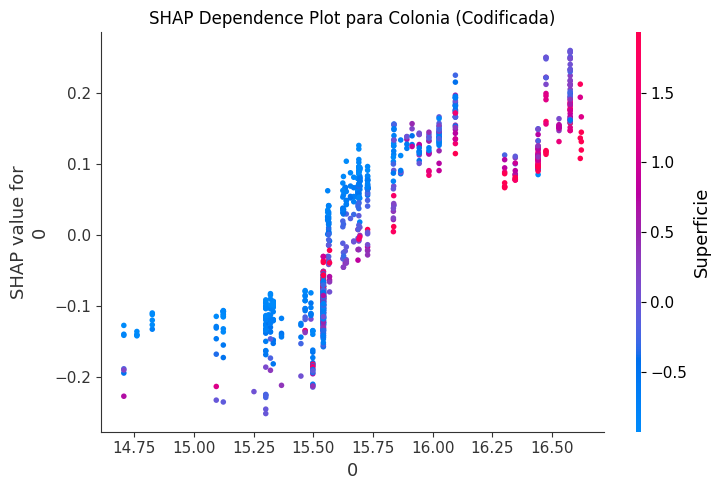

In [ ]:
import matplotlib.pyplot as plt
import shap
import numpy as np

# Obtener el índice de la característica 'Colonia' en el DataFrame preprocesado.
# Se asume que 'Colonia' es la primera característica categórica codificada por TargetEncoder,
# y su nombre en X_train_preprocessed_df es np.int64(0).

# Verificar si np.int64(0) existe en las columnas
if np.int64(0) in X_train_preprocessed_df.columns:
    colonia_feature_index = X_train_preprocessed_df.columns.get_loc(np.int64(0))
    print(f"Feature 'Colonia' (encoded as np.int64(0)) found at index {colonia_feature_index}.")

    # Usar la misma muestra que se usó para calcular shap_values
    X_sample_for_shap = X_train_preprocessed_df.sample(sample_size, random_state=RANDOM_STATE)

    # shap_values puede ser una lista o un array, aseguramos que tomamos el correcto para el modelo
    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[0] # Si es una lista, toma el primer elemento (para multi-output o CatBoost)
    else:
        shap_values_to_plot = shap_values # Si ya es un array, úsalo directamente

    # Generar el Dependence Plot para la característica 'Colonia'
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        colonia_feature_index,
        shap_values_to_plot,
        X_sample_for_shap,
        feature_names=X_train_preprocessed_df.columns,
        display_features=X_sample_for_shap,
        interaction_index="auto", # Permite a SHAP encontrar la interacción más fuerte
        show=False
    )
    plt.title('SHAP Dependence Plot para Colonia (Codificada)')
    plt.tight_layout()
    plt.show()
else:
    print("La característica np.int64(0) (correspondiente a 'Colonia' codificada) no fue encontrada en X_train_preprocessed_df.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


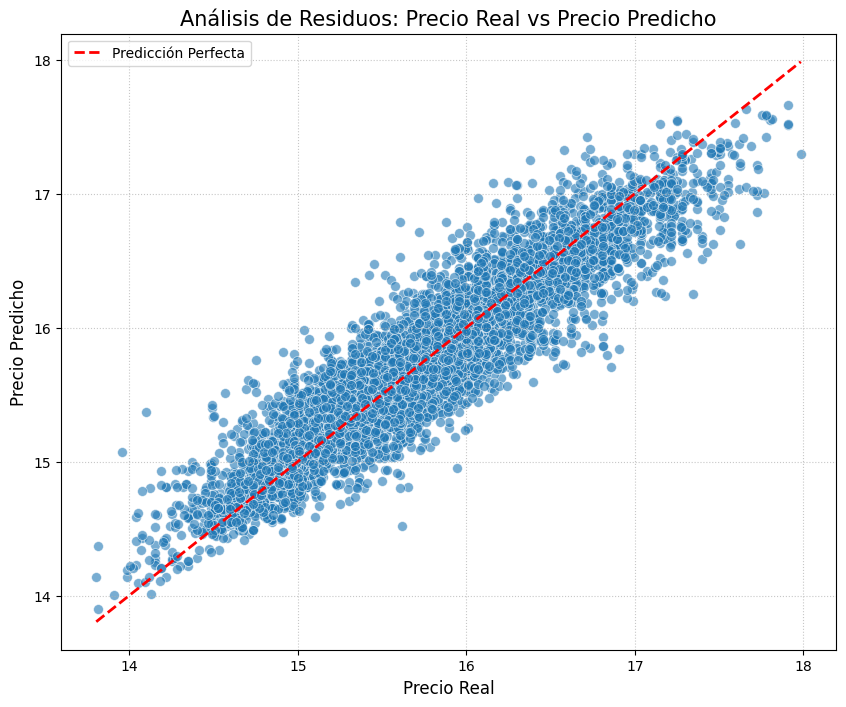

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import joblib

# Re-define necessary variables that might have been lost from the scope
# Assume TARGET and RANDOM_STATE are defined from earlier cells
TARGET = "Precio_log"
RANDOM_STATE = 42

# Load df_clean from file if not available
if 'df_clean' not in locals() and 'df_clean' not in globals():
    try:
        df_clean = pd.read_csv('df_final_clean_engineered.csv')
        print("df_clean loaded from file.")
    except FileNotFoundError:
        print("Error: 'df_final_clean_engineered.csv' not found. Cannot re-create y_test_c.")
        df_clean = None

# Ensure loaded_pipeline is available (it should be global from cell 4a945408)
if 'loaded_pipeline' not in locals() and 'loaded_pipeline' not in globals():
    try:
        loaded_pipeline = joblib.load('super_model_stacking_cdmx_final.joblib')
        print("loaded_pipeline loaded from file.")
    except FileNotFoundError:
        print("Error: 'super_model_stacking_cdmx_final.joblib' not found. Cannot make predictions.")
        loaded_pipeline = None

if df_clean is not None and loaded_pipeline is not None:
    # Re-create X_final, y_final, X_test_c, y_test_c and y_pred_f
    X_final = df_clean.drop(columns=[TARGET])
    y_final = df_clean[TARGET].values

    # Limpieza de columnas no deseadas (replicate from jJ4AitOLc2ca)
    X_final = X_final.drop(columns=[c for c in ["Direccion", "Fecha", "Web", "cluster_geo"] if c in X_final.columns], errors='ignore')

    _, X_test_c, _, y_test_c = train_test_split(X_final, y_final, test_size=0.20, random_state=RANDOM_STATE)

    y_pred_f = loaded_pipeline.predict(X_test_c)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=y_test_c,
        y=y_pred_f,
        alpha=0.6,
        edgecolor='w',
        s=50
    )

    # Línea de 45 grados para la predicción perfecta
    min_val = min(y_test_c.min(), y_pred_f.min())
    max_val = max(y_test_c.max(), y_pred_f.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta')

    plt.title('Análisis de Residuos: Precio Real vs Precio Predicho', fontsize=15)
    plt.xlabel('Precio Real', fontsize=12)
    plt.ylabel('Precio Predicho', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()
else:
    print("Cannot plot without required data or pipeline.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


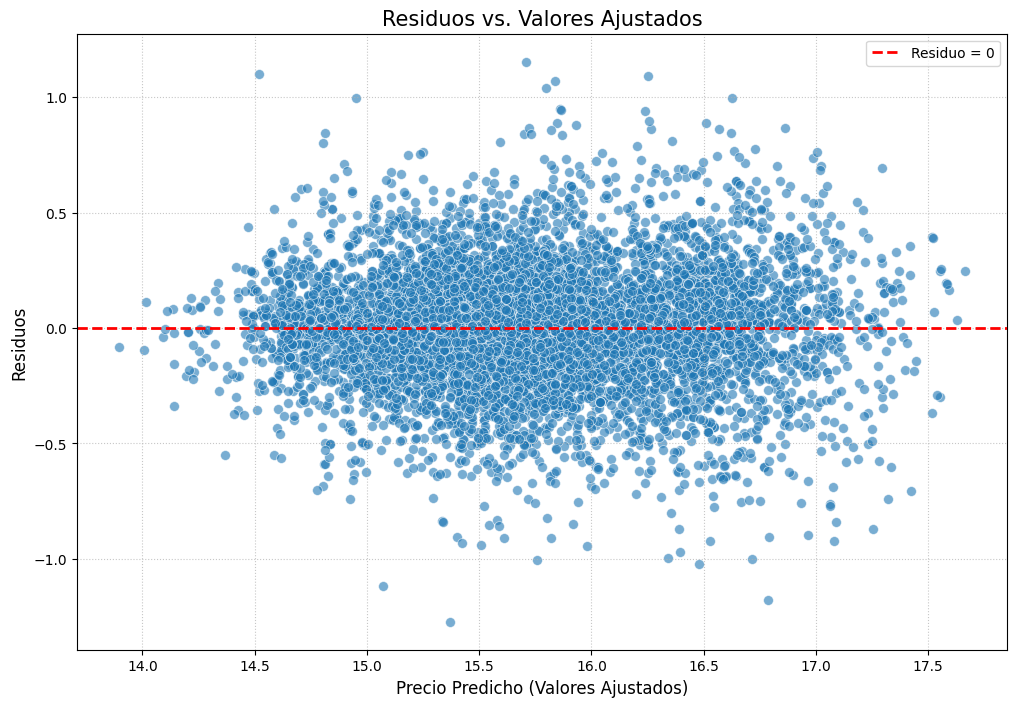

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import joblib

# Re-define necessary variables that might have been lost from the scope
# Assume TARGET and RANDOM_STATE are defined from earlier cells
TARGET = "Precio_log"
RANDOM_STATE = 42

# Load df_clean from file if not available
if 'df_clean' not in locals() and 'df_clean' not in globals():
    try:
        df_clean = pd.read_csv('df_final_clean_engineered.csv')
        print("df_clean loaded from file.")
    except FileNotFoundError:
        print("Error: 'df_final_clean_engineered.csv' not found. Cannot re-create y_test_c.")
        df_clean = None

# Ensure loaded_pipeline is available (it should be global from cell 4a945408)
if 'loaded_pipeline' not in locals() and 'loaded_pipeline' not in globals():
    try:
        loaded_pipeline = joblib.load('super_model_stacking_cdmx_final.joblib')
        print("loaded_pipeline loaded from file.")
    except FileNotFoundError:
        print("Error: 'super_model_stacking_cdmx_final.joblib' not found. Cannot make predictions.")
        loaded_pipeline = None

if df_clean is not None and loaded_pipeline is not None:
    # Re-create X_final, y_final, X_test_c, y_test_c and y_pred_f
    X_final = df_clean.drop(columns=[TARGET])
    y_final = df_clean[TARGET].values

    # Limpieza de columnas no deseadas (replicate from jJ4AitOLc2ca)
    X_final = X_final.drop(columns=[c for c in ["Direccion", "Fecha", "Web", "cluster_geo"] if c in X_final.columns], errors='ignore')

    _, X_test_c, _, y_test_c = train_test_split(X_final, y_final, test_size=0.20, random_state=RANDOM_STATE)

    y_pred_f = loaded_pipeline.predict(X_test_c)

    # Calculate residuals
    residuals = y_test_c - y_pred_f

    # Create the scatter plot of residuals vs. fitted values
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x=y_pred_f,  # Fitted values (predicted prices)
        y=residuals, # Residuals
        alpha=0.6,
        edgecolor='w',
        s=50
    )

    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')

    plt.title('Residuos vs. Valores Ajustados', fontsize=15)
    plt.xlabel('Precio Predicho (Valores Ajustados)', fontsize=12)
    plt.ylabel('Residuos', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()
else:
    print("Cannot plot without required data or pipeline.")